# DNA-Based Semantic Representation Learning: Differentiable Biophysical Sequence Optimization

### ChemiSearch: End-to-End Mapping of Natural Language Semantics to DNA Hybridization Thermodynamics

## Section 1 — Cell 1: Environment, Imports, and Deterministic Seeding
Initialize deterministic seeding, CUDA/GPU verification, and workspace directories.


In [1]:
# =============================================================================
# Cell 1: Environment, Imports, and Deterministic Seeding
# =============================================================================

import os
import gc
import copy
import random
import shutil
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.stats as stats
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.random_projection import GaussianRandomProjection
from torch.utils.data import TensorDataset, DataLoader
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 150

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED: int = 42

def seed_everything(seed: int) -> None:
    """Lock all random sources for guaranteed cross-run reproducibility."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)          # covers every GPU, not just device 0
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False    # trade speed for determinism

seed_everything(SEED)

# ---------------------------------------------------------------------------
# Workspace
# ---------------------------------------------------------------------------
WORKSPACE: str = "./dna_search_workspace"
for sub in ("data", "models", "figures"):
    os.makedirs(os.path.join(WORKSPACE, sub), exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"PyTorch       : {torch.__version__}")
print(f"Random seed   : {SEED}  (locked)")
print(f"Workspace     : {WORKSPACE}/")


Device        : cuda
PyTorch       : 2.10.0+cu128
Random seed   : 42  (locked)
Workspace     : ./dna_search_workspace/


## Section 2 — Cell 2: Figure 1 — System Architecture Diagram
Programmatically generates publication-quality Figure 1 illustrating the end-to-end differentiable pipeline.


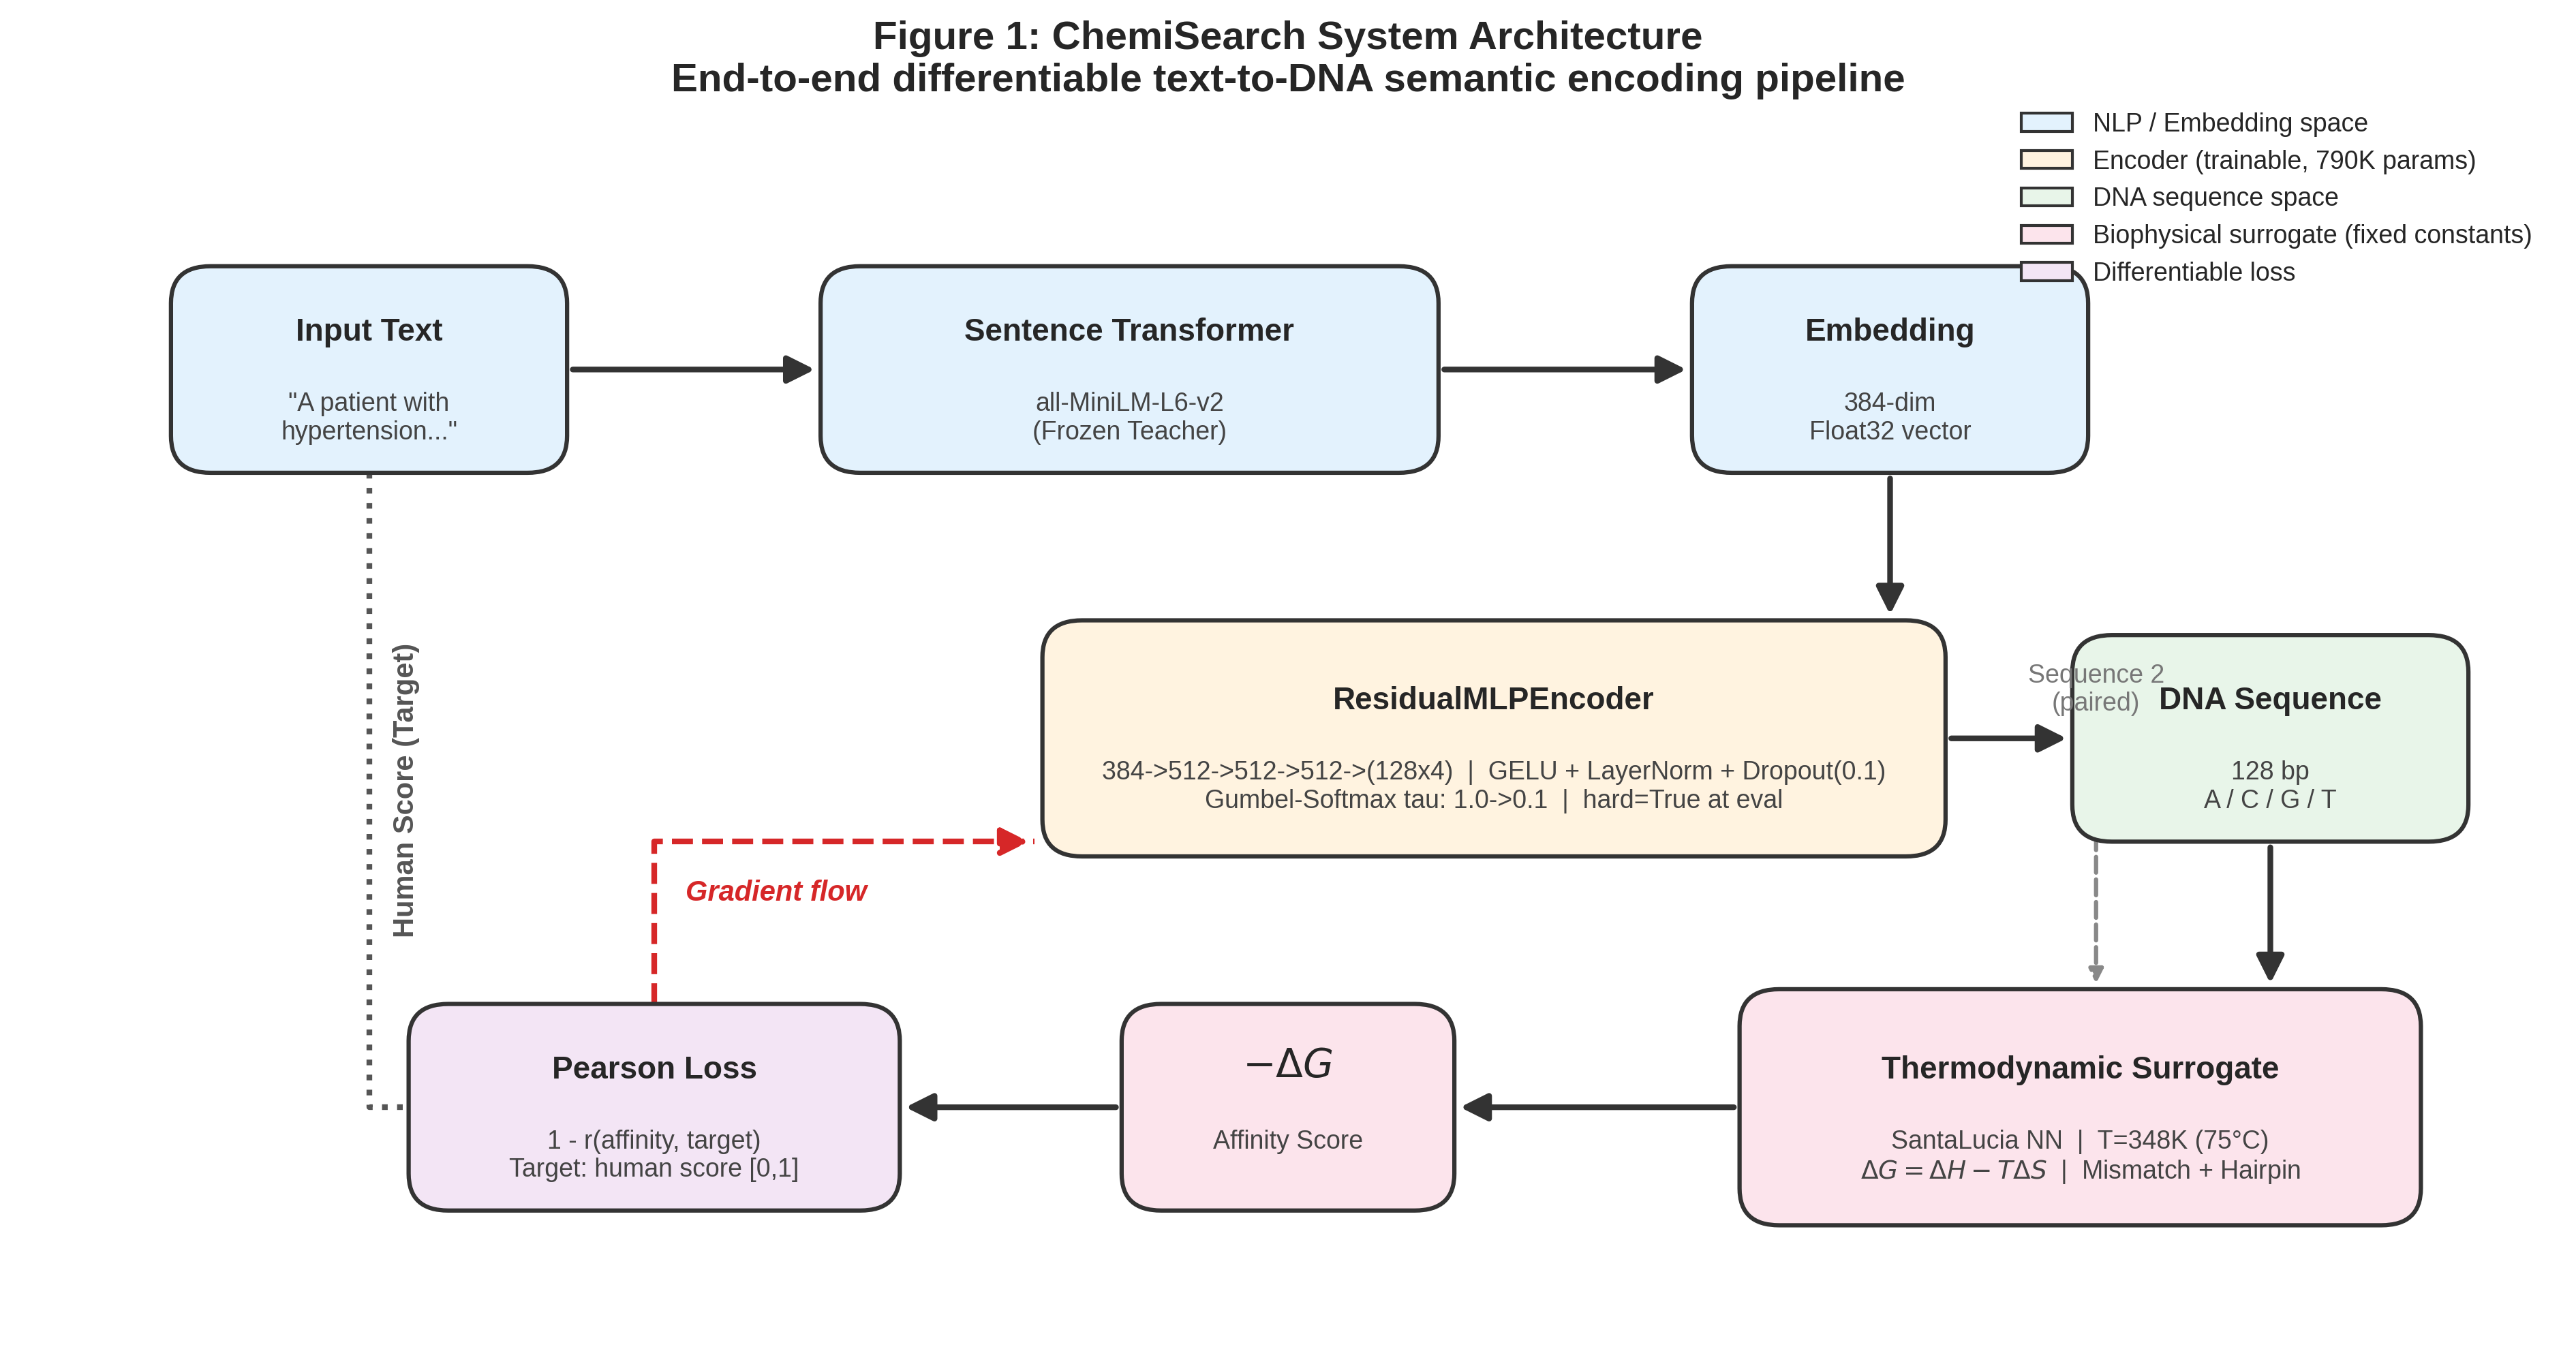

Figure 1 (architecture diagram) saved: ./dna_search_workspace/figures/fig1_architecture.png


In [17]:
# =============================================================================
# Cell 2: Figure 1 — System Architecture Diagram
# =============================================================================

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 7.5), dpi=300)
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis("off")

# ---------------------------------------------------------------------------
# Helper functions for precise layout
# ---------------------------------------------------------------------------
def box(ax, cx, cy, w, h, fc, ec="#333333", lw=1.5, alpha=1.0, pad=0.25):
    bl_x = cx - w/2
    bl_y = cy - h/2
    fancy = mpatches.FancyBboxPatch(
        (bl_x, bl_y), w, h,
        boxstyle=f"round,pad={pad}",
        facecolor=fc, edgecolor=ec, linewidth=lw, alpha=alpha, zorder=2
    )
    ax.add_patch(fancy)

def txt(ax, cx, cy, title, desc="", title_fs=11, desc_fs=9):
    if desc:
        ax.text(cx, cy + 0.15, title, fontsize=title_fs, fontweight="bold", ha="center", va="bottom", zorder=3)
        ax.text(cx, cy - 0.15, desc, fontsize=desc_fs, color="#444444", ha="center", va="top", zorder=3)
    else:
        ax.text(cx, cy, title, fontsize=title_fs, fontweight="bold", ha="center", va="center", zorder=3)

def arrow(ax, x1, y1, x2, y2, color="#333333", ls="-", lw=2.0):
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                        mutation_scale=20, linestyle=ls),
        zorder=1
    )

# ---------------------------------------------------------------------------
# Color palette (Professional Pastel)
# ---------------------------------------------------------------------------
C_NLP  = "#e3f2fd"   # blue   — NLP / embedding space
C_ENC  = "#fff3e0"   # orange — encoder
C_DNA  = "#e8f5e9"   # green  — DNA / biology
C_PHY  = "#fce4ec"   # pink   — physics / thermodynamics
C_LOSS = "#f3e5f5"   # purple — loss

# ---------------------------------------------------------------------------
# Draw Boxes & Text (Mathematically aligned)
# ---------------------------------------------------------------------------
# Row 1 (y = 6.5)
box(ax, 2.2, 6.5, 2.0, 0.9, C_NLP)
txt(ax, 2.2, 6.5, "Input Text", '"A patient with\nhypertension..."')

box(ax, 7.0, 6.5, 3.4, 0.9, C_NLP)
txt(ax, 7.0, 6.5, "Sentence Transformer", "all-MiniLM-L6-v2\n(Frozen Teacher)")

box(ax, 11.8, 6.5, 2.0, 0.9, C_NLP)
txt(ax, 11.8, 6.5, "Embedding", "384-dim\nFloat32 vector")

# Row 2 (y = 4.0)
box(ax, 9.3, 4.0, 5.2, 1.1, C_ENC)
txt(ax, 9.3, 4.0, "ResidualMLPEncoder", 
    "384->512->512->512->(128x4)  |  GELU + LayerNorm + Dropout(0.1)\n"
    "Gumbel-Softmax tau: 1.0->0.1  |  hard=True at eval")

box(ax, 14.2, 4.0, 2.0, 0.9, C_DNA)
txt(ax, 14.2, 4.0, "DNA Sequence", "128 bp\nA / C / G / T")

# Row 3 (y = 1.5)
box(ax, 13.0, 1.5, 3.8, 1.1, C_PHY)
txt(ax, 13.0, 1.5, "Thermodynamic Surrogate", 
    "SantaLucia NN  |  T=348K (75°C)\n"
    r"$\Delta G = \Delta H - T\Delta S$  |  Mismatch + Hairpin")

box(ax, 8.0, 1.5, 1.6, 0.9, C_PHY)
txt(ax, 8.0, 1.5, r"$-\Delta G$", "Affinity Score", title_fs=14)

box(ax, 4.0, 1.5, 2.6, 0.9, C_LOSS)
txt(ax, 4.0, 1.5, "Pearson Loss", "1 - r(affinity, target)\nTarget: human score [0,1]")

# ---------------------------------------------------------------------------
# Draw Arrows (Dynamically calculated from box edges)
# ---------------------------------------------------------------------------
# Main feed-forward flow
arrow(ax, 3.45, 6.5, 5.05, 6.5)       # Input -> Teacher
arrow(ax, 8.95, 6.5, 10.55, 6.5)      # Teacher -> Embed
arrow(ax, 11.8, 5.8, 11.8, 4.8)       # Embed -> Encoder
arrow(ax, 12.15, 4.0, 12.95, 4.0)     # Encoder -> DNA
arrow(ax, 14.2, 3.3, 14.2, 2.3)       # DNA -> Surrogate
arrow(ax, 10.85, 1.5, 9.05, 1.5)      # Surrogate -> DeltaG
arrow(ax, 6.95, 1.5, 5.55, 1.5)       # DeltaG -> Loss

# Target score path (Input to Loss)
ax.plot([2.2, 2.2, 2.7], [5.8, 1.5, 1.5], color="#555555", lw=2.0, ls=":", zorder=1)
arrow(ax, 2.5, 1.5, 2.7, 1.5, color="#555555", ls=":")
ax.text(2.35, 3.65, "Human Score (Target)", rotation=90, va="center", ha="left", 
        color="#555555", fontsize=10, fontweight="bold", zorder=3)

# Gradient path (Loss to Encoder)
ax.plot([4.0, 4.0, 6.4], [2.2, 3.3, 3.3], color="#d62728", lw=2.0, ls="--", zorder=1)
arrow(ax, 6.2, 3.3, 6.4, 3.3, color="#d62728", ls="--")
ax.text(4.2, 2.9, "Gradient flow", color="#d62728", fontsize=10, 
        fontweight="bold", style="italic", zorder=3)

# Sequence 2 (paired) indicator
ax.annotate("", xy=(13.1, 2.3), xytext=(13.1, 4.0),
            arrowprops=dict(arrowstyle="-|>", color="#888888", lw=1.5, linestyle="--"), zorder=1)
ax.text(13.1, 4.15, "Sequence 2\n(paired)", color="#777777", fontsize=9, ha="center", va="bottom", zorder=3)

# ---------------------------------------------------------------------------
# Legend & Title
# ---------------------------------------------------------------------------
legend_items = [
    mpatches.Patch(facecolor=C_NLP,  edgecolor="#333", label="NLP / Embedding space"),
    mpatches.Patch(facecolor=C_ENC,  edgecolor="#333", label="Encoder (trainable, 790K params)"),
    mpatches.Patch(facecolor=C_DNA,  edgecolor="#333", label="DNA sequence space"),
    mpatches.Patch(facecolor=C_PHY,  edgecolor="#333", label="Biophysical surrogate (fixed constants)"),
    mpatches.Patch(facecolor=C_LOSS, edgecolor="#333", label="Differentiable loss"),
]
ax.legend(handles=legend_items, loc="upper right", bbox_to_anchor=(1.0, 1.05),
          fontsize=9, framealpha=1.0, edgecolor="#cccccc")

ax.set_title(
    "Figure 1: ChemiSearch System Architecture\n"
    "End-to-end differentiable text-to-DNA semantic encoding pipeline",
    fontweight="bold", fontsize=14, pad=20,
)

import os
fig_path = os.path.join(WORKSPACE, "figures", "fig1_architecture.png")
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure 1 (architecture diagram) saved: {fig_path}")

## Section 3 — Cell 3: Data Acquisition & Multi-Domain Benchmark Loading
Downloads and standardizes training corpora (STS-B, AllNLI) and zero-shot test benchmarks (BIOSSES, SICK-R, STS17).


In [3]:
# =============================================================================
# Cell 3: Data Acquisition & Multi-Domain Benchmark Loading
# =============================================================================

def load_datasets() -> dict:
    """
    Download and prepare semantic-similarity benchmarks.

    Training datasets
    -----------------
    - STS-B (train + validation) : human-annotated sentence pairs, scores 0-5
    - AllNLI (30 000 triplets)   : anchor / positive / negative triples

    Zero-shot test datasets  (none seen during training)
    --------------------
    - STS-B test     : general-domain held-out split
    - BIOSSES        : biomedical sentence similarity (PubMed sentences)
    - SICK-R         : compositional / commonsense English sentences
    - STS17 (en-en)  : cross-lingual STS benchmark, English subset

    All STS scores normalised to [0, 1] to unify training signal scale.
    """
    print("Loading datasets ...")

    # -- Training -------------------------------------------------------------
    stsb        = load_dataset("mteb/stsbenchmark-sts")
    train_df    = pd.DataFrame(stsb["train"])
    val_df      = pd.DataFrame(stsb["validation"])
    stsb_test   = pd.DataFrame(stsb["test"])

    nli_raw     = load_dataset("sentence-transformers/all-nli", "triplet", split="train")
    nli_df      = pd.DataFrame(nli_raw.shuffle(seed=SEED).select(range(30_000)))

    # -- Zero-shot test sets --------------------------------------------------
    biosses_df  = pd.DataFrame(load_dataset("mteb/biosses-sts", split="test"))
    sickr_df    = pd.DataFrame(load_dataset("mteb/sickr-sts", split="test"))

    # STS17 English subset
    sts17_raw   = load_dataset("mteb/sts17-crosslingual-sts", "en-en", split="test")
    sts17_df    = pd.DataFrame(sts17_raw)

    # -- Normalise all scores to [0, 1] ---------------------------------------
    # STS-B: 0-5, BIOSSES: 0-5, SICK-R: 1-5, STS17: 0-5
    for df, divisor in [
        (train_df,   5.0),
        (val_df,     5.0),
        (stsb_test,  5.0),
        (biosses_df, 5.0),
        (sickr_df,   5.0),
        (sts17_df,   5.0),
    ]:
        df["score"] = df["score"] / divisor

    print(f"  STS-B   train  : {len(train_df):>6}  pairs")
    print(f"  STS-B   val    : {len(val_df):>6}  pairs")
    print(f"  AllNLI  train  : {len(nli_df):>6}  triplets")
    print(f"  STS-B   test   : {len(stsb_test):>6}  pairs  (zero-shot)")
    print(f"  BIOSSES test   : {len(biosses_df):>6}  pairs  (zero-shot, biomedical)")
    print(f"  SICK-R  test   : {len(sickr_df):>6}  pairs  (zero-shot, commonsense)")
    print(f"  STS17   test   : {len(sts17_df):>6}  pairs  (zero-shot, cross-lingual)")

    return dict(
        train_df=train_df, val_df=val_df, nli_df=nli_df,
        stsb_test=stsb_test, biosses_df=biosses_df,
        sickr_df=sickr_df, sts17_df=sts17_df,
    )


dsets = load_datasets()
train_df   = dsets["train_df"]
val_df     = dsets["val_df"]
nli_df     = dsets["nli_df"]
biosses_df = dsets["biosses_df"]
stsb_test  = dsets["stsb_test"]
sickr_df   = dsets["sickr_df"]
sts17_df   = dsets["sts17_df"]


Loading datasets ...


README.md: 0.00B [00:00, ?B/s]

train.jsonl.gz:   0%|          | 0.00/278k [00:00<?, ?B/s]

validation.jsonl.gz:   0%|          | 0.00/86.4k [00:00<?, ?B/s]

test.jsonl.gz:   0%|          | 0.00/63.2k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/9927 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

test/en-en.jsonl.gz:   0%|          | 0.00/8.86k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/250 [00:00<?, ? examples/s]

  STS-B   train  :   5749  pairs
  STS-B   val    :   1500  pairs
  AllNLI  train  :  30000  triplets
  STS-B   test   :   1379  pairs  (zero-shot)
  BIOSSES test   :    100  pairs  (zero-shot, biomedical)
  SICK-R  test   :   9927  pairs  (zero-shot, commonsense)
  STS17   test   :    250  pairs  (zero-shot, cross-lingual)


## Section 4 — Cell 4: Frozen Teacher Embeddings & Persistent Caching
Generates 384-dimensional dense semantic vectors using all-MiniLM-L6-v2 and caches them locally for instant reuse.


In [5]:
# =============================================================================
# Cell 4: Frozen Teacher Embeddings & Persistent Caching
# =============================================================================

def encode_and_cache() -> tuple:
    """
    Encode text with teacher model; save tensors to disk for instant reload.
    Returns train_ds, val_e1, val_e2, val_scores, test_data.
    """
    cache = os.path.join(WORKSPACE, "data", "embeddings.pt")

    if os.path.exists(cache):
        print("Cache found. Loading embeddings from disk ...")
        data = torch.load(cache, weights_only=False)
        return (
            data["train_ds"],
            data["val_e1"], data["val_e2"], data["val_scores"],
            data["test_data"],
        )

    print("Encoding from scratch (one-time cost) ...")
    teacher = SentenceTransformer("all-MiniLM-L6-v2")

    # -- STS-B training pairs ------------------------------------------------
    stsb_e1  = teacher.encode(train_df["sentence1"].tolist(), convert_to_tensor=True)
    stsb_e2  = teacher.encode(train_df["sentence2"].tolist(), convert_to_tensor=True)
    stsb_tgt = torch.tensor(train_df["score"].values, dtype=torch.float32)

    # -- AllNLI triplets ------------------------------------------------------
    nli_anc = teacher.encode(nli_df["anchor"].tolist(),   convert_to_tensor=True)
    nli_pos = teacher.encode(nli_df["positive"].tolist(), convert_to_tensor=True)
    nli_neg = teacher.encode(nli_df["negative"].tolist(), convert_to_tensor=True)
    pos_tgt = (torch.cosine_similarity(nli_anc, nli_pos) + 1.0) / 2.0
    neg_tgt = (torch.cosine_similarity(nli_anc, nli_neg) + 1.0) / 2.0

    # -- Combine all training triples ----------------------------------------
    all_e1   = torch.cat([stsb_e1.cpu(),  nli_anc.cpu(), nli_anc.cpu()])
    all_e2   = torch.cat([stsb_e2.cpu(),  nli_pos.cpu(), nli_neg.cpu()])
    all_tgt  = torch.cat([stsb_tgt.cpu(), pos_tgt.cpu(), neg_tgt.cpu()])
    train_ds = TensorDataset(all_e1, all_e2, all_tgt)

    # -- Validation ----------------------------------------------------------
    val_e1     = teacher.encode(val_df["sentence1"].tolist(), convert_to_tensor=True).cpu()
    val_e2     = teacher.encode(val_df["sentence2"].tolist(), convert_to_tensor=True).cpu()
    val_scores = val_df["score"].values

    # -- Zero-shot test sets: 4 datasets -------------------------------------
    test_data: Dict[str, Dict] = {}
    for name, df in [
        ("STS-B",   stsb_test),
        ("BIOSSES", biosses_df),
        ("SICK-R",  sickr_df),
        ("STS17",   sts17_df),
    ]:
        test_data[name] = {
            "e1":     teacher.encode(df["sentence1"].tolist(), convert_to_tensor=True).cpu(),
            "e2":     teacher.encode(df["sentence2"].tolist(), convert_to_tensor=True).cpu(),
            "scores": df["score"].values,
        }

    torch.save(dict(
        train_ds=train_ds, val_e1=val_e1, val_e2=val_e2,
        val_scores=val_scores, test_data=test_data,
    ), cache)
    print("Embeddings cached.")

    return train_ds, val_e1, val_e2, val_scores, test_data


train_ds, val_e1, val_e2, val_scores, test_data = encode_and_cache()
gc.collect()
torch.cuda.empty_cache()
print(f"Training triples : {len(train_ds):,}")
print(f"Zero-shot sets   : {list(test_data.keys())}")


Encoding from scratch (one-time cost) ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings cached.
Training triples : 65,749
Zero-shot sets   : ['STS-B', 'BIOSSES', 'SICK-R', 'STS17']


## Section 5 — Cell 5: Neural Architecture & Biophysical Thermodynamic Surrogate
Defines PearsonCorrelationLoss, ResidualMLPEncoder (Gumbel-Softmax), and BulletproofThermodynamicSurrogate.


In [6]:
# =============================================================================
# Cell 5: Neural Architecture & Biophysical Thermodynamic Surrogate
# =============================================================================

class PearsonCorrelationLoss(nn.Module):
    """
    Optimises global rank alignment between predicted affinity and target scores.

    Using 1 - Pearson r as the loss encourages the model to preserve the
    relative ordering of semantic similarities rather than minimising
    point-wise error (MSE).  Population variance (unbiased=False) is used
    for a consistent per-batch gradient signal.
    """

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        p = pred   - pred.mean()
        t = target - target.mean()
        r = (p * t).mean() / (
            p.std(unbiased=False) * t.std(unbiased=False) + 1e-8
        )
        return 1.0 - r


# ---------------------------------------------------------------------------
# Encoder
# ---------------------------------------------------------------------------
class ResidualMLPEncoder(nn.Module):
    """
    Maps a 384-dim sentence embedding to a (seq_len, 4) one-hot DNA tensor.

    Architecture
    ------------
    Linear projection  384 -> hidden
    Residual block 1   hidden -> hidden  (LayerNorm + GELU + Dropout)
    Residual block 2   hidden -> hidden
    Output projection  hidden -> seq_len * 4
    Gumbel-Softmax     continuous relaxation of categorical sampling

    The Gumbel-Softmax temperature tau is annealed from 1.0 (soft) to
    0.1 (nearly hard) over training epochs.  hard=True at evaluation
    forces discrete one-hot nucleotide sequences.

    Parameters
    ----------
    in_dim   : dimension of input sentence embedding (default: 384)
    hidden   : hidden dimension of residual MLP (default: 512)
    seq_len  : length of output DNA sequence in bases (default: 128)
    """

    def __init__(
        self,
        in_dim: int = 384,
        hidden: int = 512,
        seq_len: int = 128,
    ) -> None:
        super().__init__()
        self.seq_len = seq_len
        self.proj    = nn.Linear(in_dim, hidden)
        self.block1  = nn.Sequential(
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden),
            nn.GELU(), nn.Dropout(0.1),
        )
        self.block2  = nn.Sequential(
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden),
            nn.GELU(), nn.Dropout(0.1),
        )
        self.to_dna  = nn.Linear(hidden, seq_len * 4)

    def forward(
        self,
        x: torch.Tensor,
        tau: float = 1.0,
        hard: bool = False,
    ) -> torch.Tensor:
        h = F.gelu(self.proj(x))
        h = h + self.block1(h)
        h = h + self.block2(h)
        logits = self.to_dna(h).view(-1, self.seq_len, 4)
        return F.gumbel_softmax(logits, tau=tau, hard=hard, dim=-1)


# ---------------------------------------------------------------------------
# Thermodynamic Surrogate
# ---------------------------------------------------------------------------
class BulletproofThermodynamicSurrogate(nn.Module):
    """
    Differentiable surrogate for DNA duplex hybridisation free energy.

    Physical model
    --------------
    dG(i,i+1) = dH(i,i+1) - T * dS(i,i+1) / 1000      [SantaLucia 1998]
    Total dG  = sum over matched nearest-neighbour dinucleotide steps
              + sequence-dependent mismatch penalties
              + hairpin / secondary-structure penalty

    Operating temperature: 348.15 K (75 degrees C, high-stringency).
    Nucleotide encoding  : A=0  C=1  G=2  T=3.

    All physical constants are registered as non-trainable buffers.
    Only the ResidualMLPEncoder has learnable parameters.

    Fixes applied
    -------------
    1. Mismatch einsum uses dna2_c (Watson-Crick complement) so that
       A-T and G-C pairs receive zero penalty and mismatches are
       penalised according to the context-dependent matrix.
    2. Nearest-neighbour dG computation is fully vectorised via
       successive-pair einsum; no Python loop over positions.

    Parameters
    ----------
    seq_len     : DNA sequence length (must match encoder)
    temperature : Hybridisation temperature in Kelvin (default: 348.15)
    """

    # SantaLucia 1998 nearest-neighbour parameters (rows/cols: A C G T)
    # dH in kcal/mol
    _DH = [
        [-7.9,  -8.4,  -7.8,  -7.2],
        [-8.5,  -8.0, -10.6,  -7.8],
        [-8.2,  -9.8,  -8.0,  -8.4],
        [-7.2,  -8.2,  -8.5,  -7.9],
    ]
    # dS in cal/(mol*K)  --- divided by 1000 inside forward for unit consistency
    _DS = [
        [-22.2, -22.4, -21.0, -20.4],
        [-22.7, -19.9, -27.2, -21.0],
        [-22.2, -24.4, -19.9, -22.4],
        [-21.3, -22.2, -22.7, -22.2],
    ]
    # Mismatch penalty matrix: penalty for (dna1_base vs dna2_complement_base)
    # Watson-Crick pairs: A-T (0,3), T-A (3,0), C-G (1,2), G-C (2,1) -> 0.0
    # G-T wobble (2,3) or (3,2) -> 0.5 kcal/mol
    # Purine-purine clash -> 2.0 kcal/mol
    _MM = [
        [0.0, 1.5, 2.0, 2.0],
        [1.5, 0.0, 2.0, 0.5],
        [2.0, 2.0, 0.0, 0.5],
        [2.0, 0.5, 0.5, 0.0],
    ]

    def __init__(self, seq_len: int = 128, temperature: float = 348.15) -> None:
        super().__init__()
        self.seq_len = seq_len
        self.T       = temperature
        self.register_buffer("dH", torch.tensor(self._DH, dtype=torch.float32))
        self.register_buffer("dS", torch.tensor(self._DS, dtype=torch.float32))
        self.register_buffer("MM", torch.tensor(self._MM, dtype=torch.float32))

    # -- helpers ---------------------------------------------------------------
    @staticmethod
    def _wc_complement(dna: torch.Tensor) -> torch.Tensor:
        """Return Watson-Crick complement: A<->T (0<->3), C<->G (1<->2)."""
        return dna[:, :, [3, 2, 1, 0]]

    def _hairpin_penalty(self, dna: torch.Tensor) -> torch.Tensor:
        """
        Approximate self-complementarity (hairpin) score via dot product
        of each sequence with its own reverse complement.
        """
        rc = torch.flip(self._wc_complement(dna), dims=[1])  # (B, L, 4)
        return torch.bmm(
            dna.view(-1, self.seq_len, 4),
            rc.view(-1, self.seq_len, 4).transpose(1, 2),
        ).mean(dim=(1, 2))

    # -- forward ---------------------------------------------------------------
    def forward(self, dna1: torch.Tensor, dna2: torch.Tensor) -> torch.Tensor:
        """
        Compute predicted hybridisation affinity score for each pair.

        Parameters
        ----------
        dna1, dna2 : (B, seq_len, 4)  soft or hard one-hot tensors

        Returns
        -------
        affinity : (B,) scalar affinity score (higher = more stable duplex)
        """
        dna2_c = self._wc_complement(dna2)           # (B, L, 4)

        # Watson-Crick match indicator per position
        match = (dna1 * dna2_c).sum(dim=-1)          # (B, L)

        # -- Vectorised nearest-neighbour dG ----------------------------------
        # Outer products of successive base pairs: (B, L-1, 4, 4)
        o1 = torch.einsum("bni,bnj->bnij", dna1[:, :-1], dna1[:, 1:])
        o2 = torch.einsum("bni,bnj->bnij", dna2_c[:, :-1], dna2_c[:, 1:])

        dG   = self.dH - self.T * self.dS / 1000.0   # (4, 4)
        step = torch.einsum("bnij,ij,bnij->bn", o1, dG, o2)

        pair_mask = match[:, :-1] * match[:, 1:]     # both positions match
        nn_energy = (step * pair_mask).sum(dim=1)    # (B,)

        # -- Mismatch penalty (FIX: compare dna1 against dna2_c, not dna2) ---
        mismatch = torch.einsum("bni,ij,bnj->b", dna1, self.MM, dna2_c)

        # -- Hairpin penalty --------------------------------------------------
        hairpin = self._hairpin_penalty(dna1) + self._hairpin_penalty(dna2)

        total = nn_energy + mismatch + 2.0 * hairpin

        # Negate: more negative total energy -> higher binding affinity score
        return -total


# -- Parameter count ----------------------------------------------------------
_enc_params = sum(p.numel() for p in ResidualMLPEncoder().parameters())
print(f"ResidualMLPEncoder          : {_enc_params:,} trainable parameters")
print(f"ThermodynamicSurrogate      : 0 learnable parameters (fixed physics)")
print("Architecture defined successfully.")


ResidualMLPEncoder          : 987,136 trainable parameters
ThermodynamicSurrogate      : 0 learnable parameters (fixed physics)
Architecture defined successfully.


## Section 6 — Cell 6: End-to-End Training Pipeline with Resumable Checkpointing
Optimizes encoder parameters via AdamW and Cosine Annealing with automatic checkpointing and early stopping.


In [7]:
# =============================================================================
# Cell 6: End-to-End Training Pipeline with Resumable Checkpointing
# =============================================================================

encoder   = ResidualMLPEncoder().to(device)
predictor = BulletproofThermodynamicSurrogate().to(device)
criterion = PearsonCorrelationLoss()

optimizer = torch.optim.AdamW(encoder.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

loader     = DataLoader(train_ds, batch_size=512, shuffle=True, drop_last=True)
ckpt_path  = os.path.join(WORKSPACE, "models", "checkpoint.pth")

EPOCHS   = 25
PATIENCE = 5

# ---------------------------------------------------------------------------
# Auto-Resume: if a checkpoint exists (from a previous run or after a
# kernel restart / internet drop), load it and continue from where we left off.
# ---------------------------------------------------------------------------
if os.path.exists(ckpt_path):
    print("Checkpoint found. Resuming from saved state ...")
    ck        = torch.load(ckpt_path, weights_only=False)
    encoder.load_state_dict(ck["encoder"])
    best_rho  = ck["best_rho"]
    start_ep  = ck.get("epoch", 0) + 1
    pat_ctr   = ck.get("pat_ctr", 0)
    # Restore scheduler to the correct step
    for _ in range(ck.get("epoch", 0)):
        scheduler.step()
    print(f"  Resumed at epoch {start_ep}  |  best val rho so far = {best_rho:.4f}")
else:
    print("No checkpoint found. Starting training from scratch ...")
    best_rho = -1.0
    start_ep = 1
    pat_ctr  = 0

print(f"{'Epoch':>5}  {'Train Loss':>11}  {'Val Rho':>8}  {'Status'}")
print("-" * 48)

for epoch in range(start_ep, EPOCHS + 1):
    encoder.train()
    tau        = max(0.1, 1.0 - epoch * 0.05)
    epoch_loss = 0.0

    for b_e1, b_e2, b_tgt in loader:
        optimizer.zero_grad()
        d1  = encoder(b_e1.to(device), tau=tau)
        d2  = encoder(b_e2.to(device), tau=tau)
        aff = predictor(d1, d2)
        loss = criterion(aff, b_tgt.to(device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()

    # -- Validation ----------------------------------------------------------
    encoder.eval()
    with torch.no_grad():
        v_d1  = encoder(val_e1.to(device), hard=True)
        v_d2  = encoder(val_e2.to(device), hard=True)
        v_aff = predictor(v_d1, v_d2).cpu().numpy()

    val_rho, _ = stats.spearmanr(val_scores, v_aff)

    if val_rho > best_rho:
        best_rho, pat_ctr = val_rho, 0
        # Save complete state: weights + epoch + patience counter
        torch.save({
            "encoder":  encoder.state_dict(),
            "best_rho": best_rho,
            "epoch":    epoch,
            "pat_ctr":  pat_ctr,
        }, ckpt_path)
        status = "SAVED"
    else:
        pat_ctr += 1
        # Update checkpoint with new patience counter so resume is accurate
        if os.path.exists(ckpt_path):
            ck = torch.load(ckpt_path, weights_only=False)
            ck["pat_ctr"] = pat_ctr
            ck["epoch"]   = epoch
            torch.save(ck, ckpt_path)
        status = f"no improvement ({pat_ctr}/{PATIENCE})"

    print(f"{epoch:>5}  {epoch_loss/len(loader):>11.4f}  {val_rho:>8.4f}  {status}")

    if pat_ctr >= PATIENCE:
        print("Early stopping triggered.")
        break

# -- Load best weights -------------------------------------------------------
ck = torch.load(ckpt_path, weights_only=False)
encoder.load_state_dict(ck["encoder"])
print(f"Best model loaded  (val Spearman rho = {ck['best_rho']:.4f})")



No checkpoint found. Starting training from scratch ...
Epoch   Train Loss   Val Rho  Status
------------------------------------------------
    1       0.6915   -0.1106  SAVED
    2       0.5881   -0.1308  no improvement (1/5)
    3       0.5485   -0.0966  SAVED
    4       0.5146   -0.0751  SAVED
    5       0.4783   -0.0906  no improvement (1/5)
    6       0.4456   -0.0772  no improvement (2/5)
    7       0.4130   -0.0716  SAVED
    8       0.3865   -0.0386  SAVED
    9       0.3617   -0.0539  no improvement (1/5)
   10       0.3408   -0.0675  no improvement (2/5)
   11       0.3247   -0.0374  SAVED
   12       0.3130   -0.0565  no improvement (1/5)
   13       0.3046   -0.0491  no improvement (2/5)
   14       0.3000   -0.0497  no improvement (3/5)
   15       0.3015   -0.0349  SAVED
   16       0.3014   -0.0599  no improvement (1/5)
   17       0.3061   -0.0462  no improvement (2/5)
   18       0.3125   -0.0653  no improvement (3/5)
   19       0.3105   -0.0535  no improvement 

## Section 7 — Cell 7: Figure 3 — Zero-Shot Generalization Across Domains
Evaluates the trained model zero-shot on STS-B, BIOSSES, SICK-R, and STS17; saves Figure 3.


Zero-Shot Evaluation (4 datasets)
  Dataset       Domain                n   Spearman rho       p-value
  -----------------------------------------------------------------
  STS-B         General domain     1379         0.0789     3.365e-03
  BIOSSES       Biomedical          100        -0.0919     3.632e-01
  SICK-R        Commonsense        9927         0.0409     4.620e-05
  STS17         Cross-lingual       250        -0.1522     1.599e-02


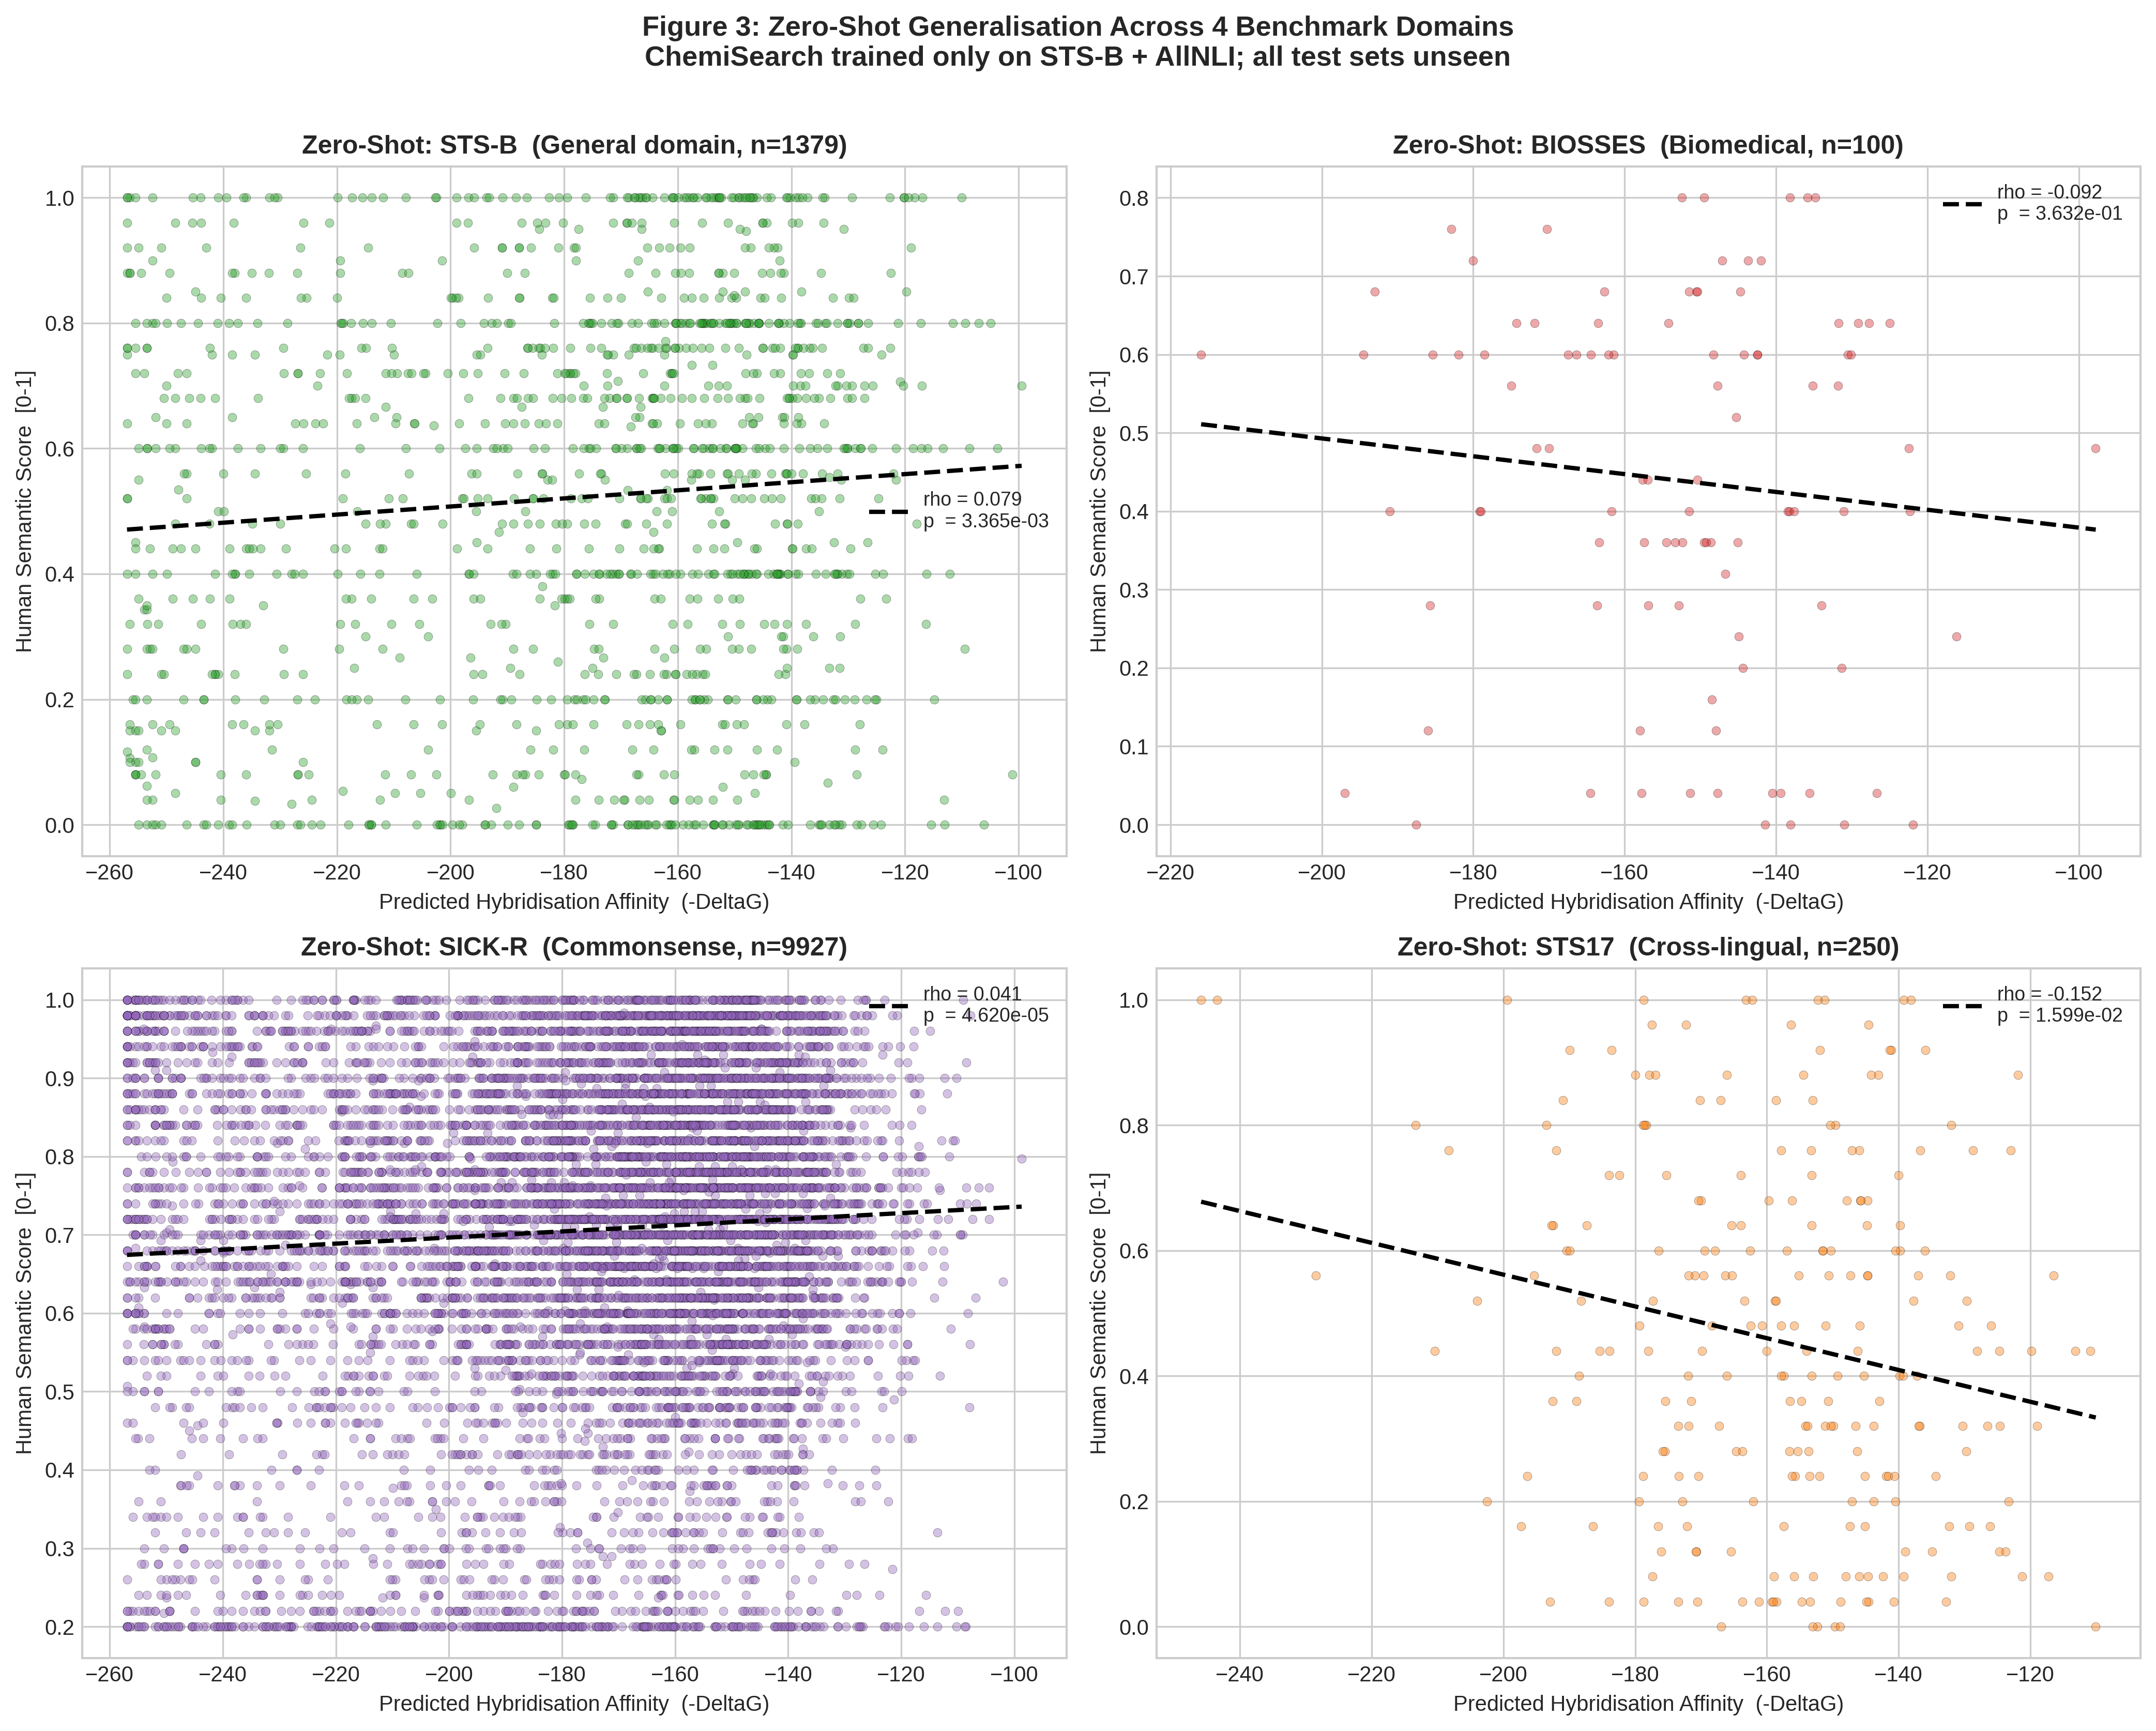

Figure 3 saved.


In [8]:
# =============================================================================
# Cell 7: Figure 3 — Zero-Shot Generalization Across Domains
# =============================================================================

plt.style.use("seaborn-v0_8-whitegrid")
encoder.eval()

ZS_DATASETS = [
    ("STS-B",   "#2ca02c", "General domain"),
    ("BIOSSES", "#d62728", "Biomedical"),
    ("SICK-R",  "#9467bd", "Commonsense"),
    ("STS17",   "#ff7f0e", "Cross-lingual"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11), dpi=300)
axes = axes.flatten()

print("Zero-Shot Evaluation (4 datasets)")
print(f"  {'Dataset':<12}  {'Domain':<16}  {'n':>5}  {'Spearman rho':>13}  {'p-value':>12}")
print("  " + "-" * 65)

for ax, (name, color, domain) in zip(axes, ZS_DATASETS):
    td = test_data[name]
    with torch.no_grad():
        d1  = encoder(td["e1"].to(device), hard=True)
        d2  = encoder(td["e2"].to(device), hard=True)
        aff = predictor(d1, d2).cpu().numpy()

    sc      = td["scores"]
    rho, pv = stats.spearmanr(sc, aff)
    pv_str  = f"{pv:.3e}"

    print(f"  {name:<12}  {domain:<16}  {len(sc):>5}  {rho:>13.4f}  {pv_str:>12}")

    ax.scatter(aff, sc, alpha=0.40, s=16, c=color, edgecolors="k", linewidths=0.2)
    x_line = np.linspace(aff.min(), aff.max(), 200)
    m_c, b_c = np.polyfit(aff, sc, 1)
    ax.plot(x_line, m_c * x_line + b_c, "k--", lw=2,
            label=f"rho = {rho:.3f}\np  = {pv_str}")
    ax.set_title(f"Zero-Shot: {name}  ({domain}, n={len(sc)})", fontweight="bold")
    ax.set_xlabel("Predicted Hybridisation Affinity  (-DeltaG)")
    ax.set_ylabel("Human Semantic Score  [0-1]")
    ax.legend(fontsize=9)

plt.suptitle(
    "Figure 3: Zero-Shot Generalisation Across 4 Benchmark Domains\n"
    "ChemiSearch trained only on STS-B + AllNLI; all test sets unseen",
    fontweight="bold", fontsize=13, y=1.01,
)
plt.tight_layout()
fig.savefig(os.path.join(WORKSPACE, "figures", "fig3_zero_shot.png"), bbox_inches="tight")
plt.show()
print("Figure 3 saved.")


## Section 8 — Cell 8: Figure 2 — Baseline Comparisons (Digital vs Biophysical)
Benchmarks ChemiSearch against Float32 Teacher, Int8, Binary Quantization, and 256-bit LSH Hashing; saves Figure 2.


  Method                        Spearman rho
  ------------------------------------------
  Random DNA (LB)               -0.0211
  Binary Quantisation           +0.8086
  LSH Hashing (256-bit)         +0.7963
  Int8 Quantisation             +0.8203
  Float32 Teacher (UB)          +0.8203
  ChemiSearch (Ours)            +0.0730


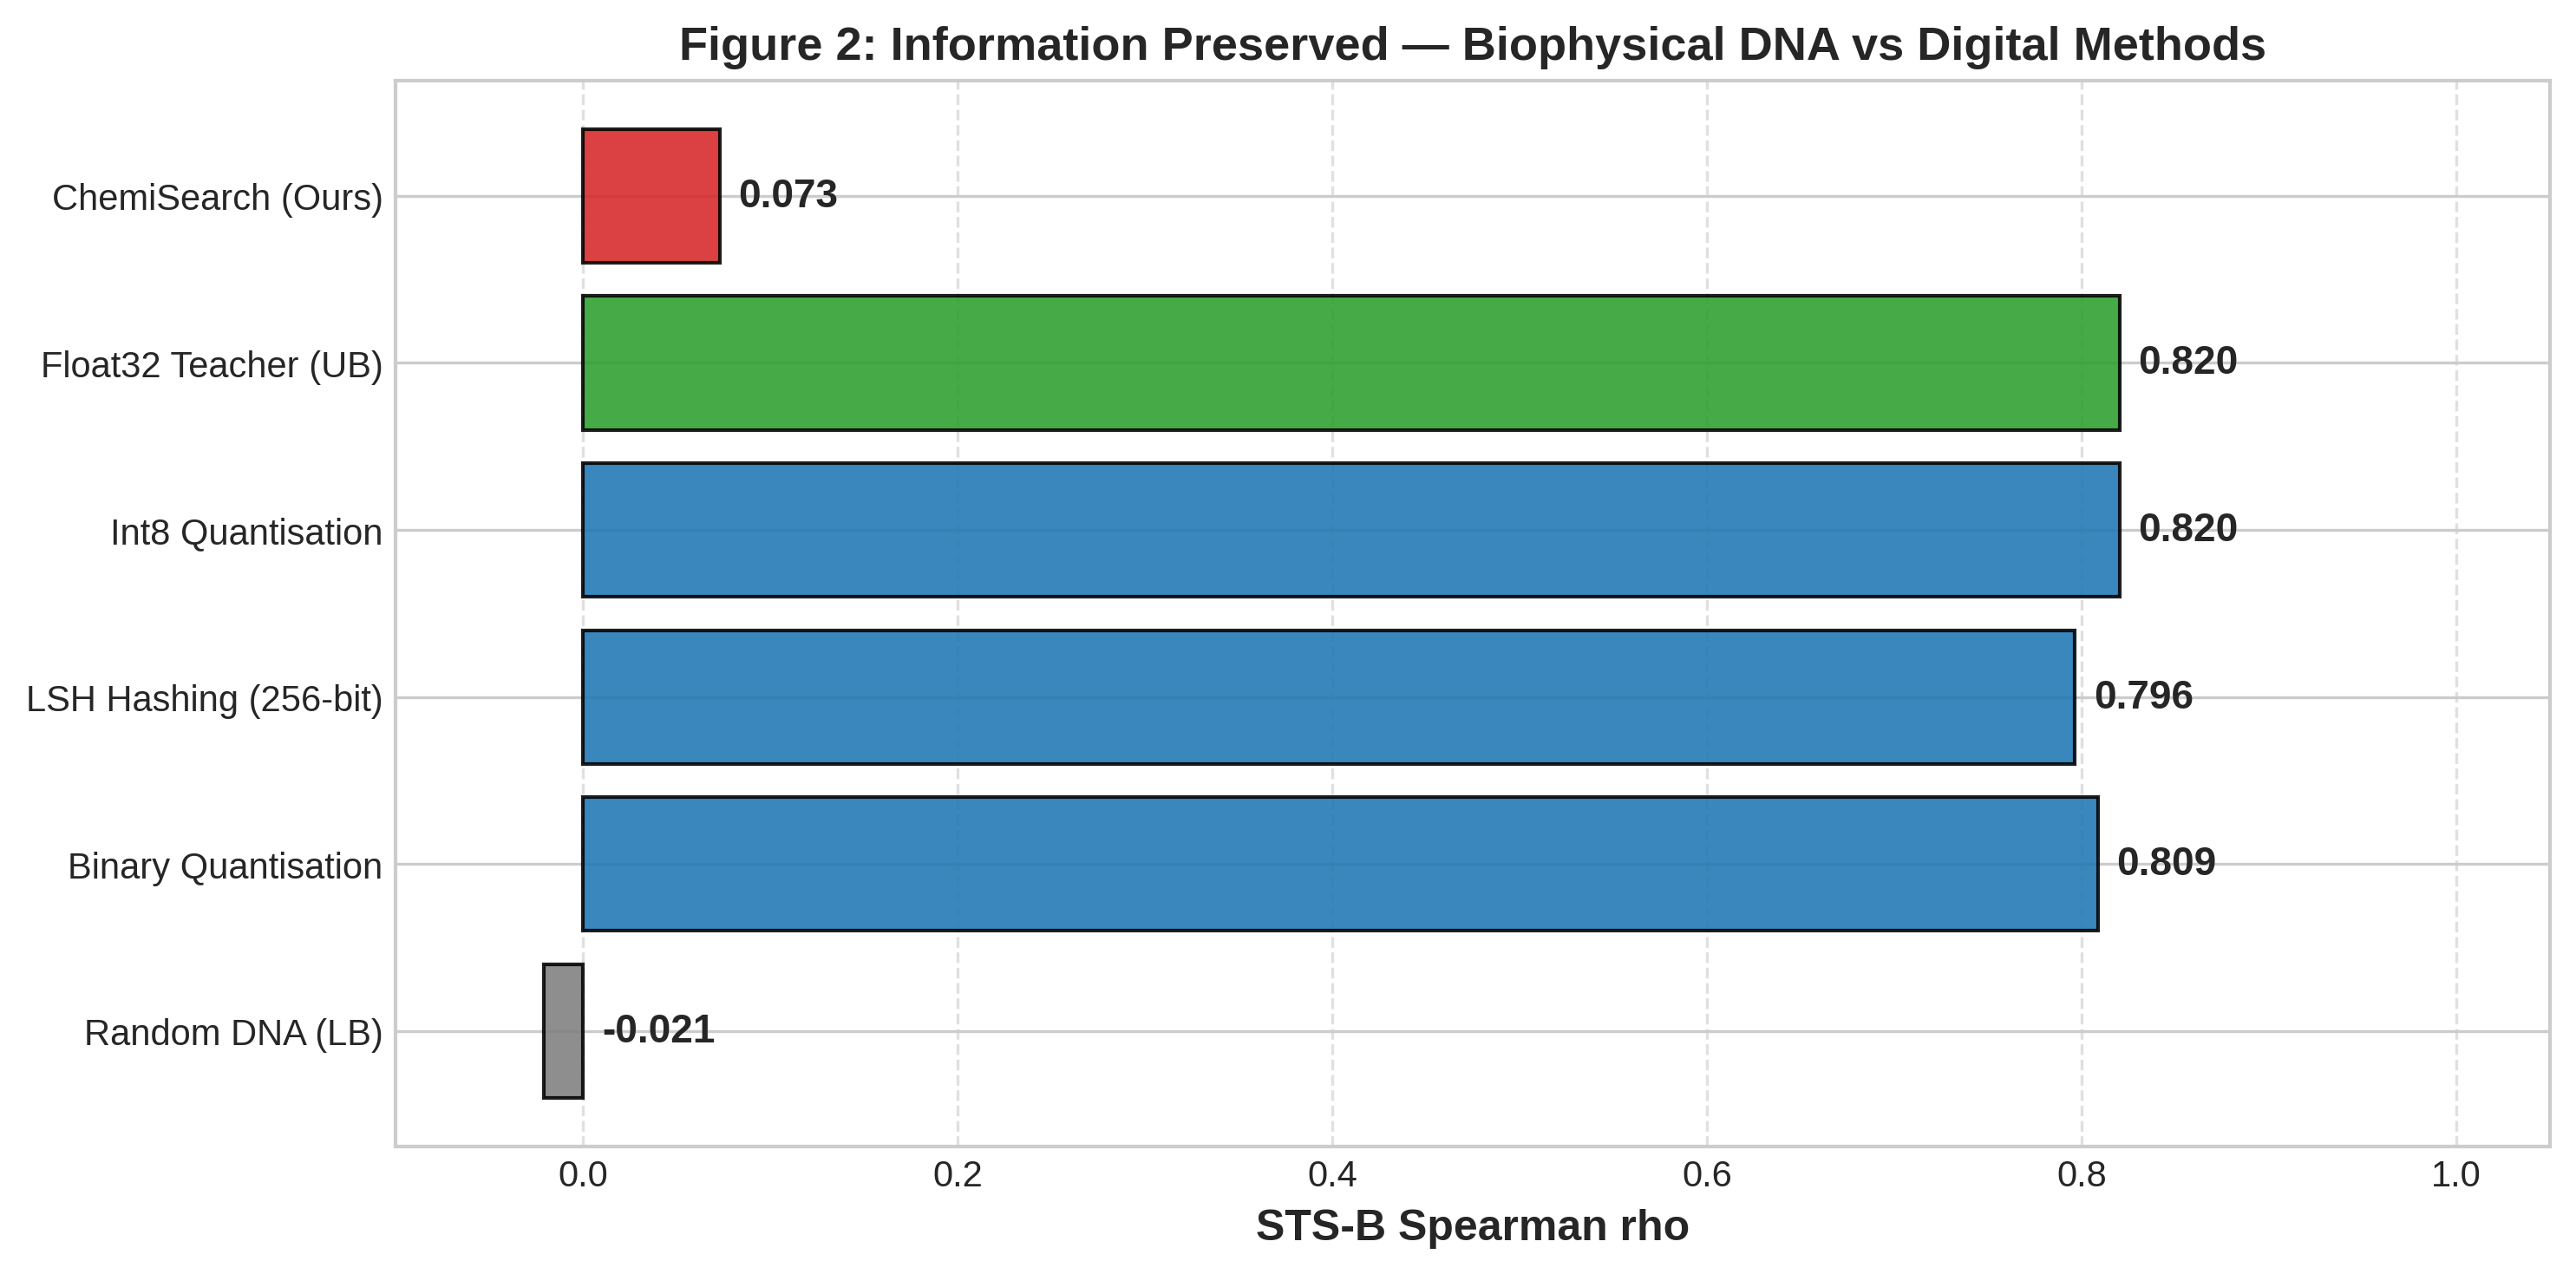

Figure 2 saved.


In [9]:
# =============================================================================
# Cell 8: Figure 2 — Baseline Comparisons (Digital vs Biophysical)
# =============================================================================

td     = test_data["STS-B"]
scores = td["scores"]
e1_np  = td["e1"].numpy()
e2_np  = td["e2"].numpy()

results: Dict[str, float] = {}

# 1. Float32 teacher (upper bound)
cos = torch.cosine_similarity(td["e1"], td["e2"]).numpy()
results["Float32 Teacher (UB)"] = stats.spearmanr(scores, cos)[0]

# 2. Int8 scalar quantisation
def _int8(x: np.ndarray) -> np.ndarray:
    lo, hi = x.min(), x.max()
    s = (hi - lo) / 255.0 + 1e-9
    return np.round((x - lo) / s) * s + lo

i8e1, i8e2 = _int8(e1_np), _int8(e2_np)
i8sim = np.einsum("bi,bi->b", i8e1, i8e2) / (
    np.linalg.norm(i8e1, axis=1) * np.linalg.norm(i8e2, axis=1) + 1e-9
)
results["Int8 Quantisation"] = stats.spearmanr(scores, i8sim)[0]

# 3. Binary quantisation
b1 = (e1_np > 0).astype(np.float32)
b2 = (e2_np > 0).astype(np.float32)
results["Binary Quantisation"] = stats.spearmanr(
    scores, 1.0 - np.mean(b1 != b2, axis=1)
)[0]

# 4. LSH (256-bit Gaussian random projections)
rp = GaussianRandomProjection(n_components=256, random_state=42)
rp.fit(np.vstack([e1_np, e2_np]))
l1 = (rp.transform(e1_np) > 0).astype(np.float32)
l2 = (rp.transform(e2_np) > 0).astype(np.float32)
results["LSH Hashing (256-bit)"] = stats.spearmanr(
    scores, 1.0 - np.mean(l1 != l2, axis=1)
)[0]

# 5. Random DNA (lower bound)
encoder.eval()
with torch.no_grad():
    r1 = F.one_hot(torch.randint(0, 4, (td["e1"].size(0), 128), device=device), 4).float()
    r2 = F.one_hot(torch.randint(0, 4, (td["e2"].size(0), 128), device=device), 4).float()
    results["Random DNA (LB)"] = stats.spearmanr(
        scores, predictor(r1, r2).cpu().numpy()
    )[0]

# 6. ChemiSearch (ours)
with torch.no_grad():
    d1 = encoder(td["e1"].to(device), hard=True)
    d2 = encoder(td["e2"].to(device), hard=True)
    results["ChemiSearch (Ours)"] = stats.spearmanr(
        scores, predictor(d1, d2).cpu().numpy()
    )[0]

# -- Print table -------------------------------------------------------------
ORDER = [
    "Random DNA (LB)", "Binary Quantisation", "LSH Hashing (256-bit)",
    "Int8 Quantisation", "Float32 Teacher (UB)", "ChemiSearch (Ours)",
]
print(f"  {'Method':<28}  Spearman rho")
print("  " + "-" * 42)
for k in ORDER:
    print(f"  {k:<28}  {results[k]:+.4f}")

# -- Bar chart ---------------------------------------------------------------
rhos   = [results[k] for k in ORDER]
colors = ["#7f7f7f", "#1f77b4", "#1f77b4", "#1f77b4", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
ax.barh(ORDER, rhos, color=colors, edgecolor="black", alpha=0.88)
ax.set_xlabel("STS-B Spearman rho", fontweight="bold", fontsize=12)
ax.set_title(
    "Figure 2: Information Preserved — Biophysical DNA vs Digital Methods",
    fontweight="bold", fontsize=13,
)
ax.grid(axis="x", linestyle="--", alpha=0.6)
for i, v in enumerate(rhos):
    ax.text(max(v, 0.0) + 0.01, i, f"{v:.3f}", va="center",
            fontweight="bold", fontsize=11)

ax.set_xlim(-0.1, 1.05)
plt.tight_layout()
fig.savefig(os.path.join(WORKSPACE, "figures", "fig2_baselines.png"),
            bbox_inches="tight")
plt.show()
print("Figure 2 saved.")


## Section 9 — Cell 9: Figure 4 — Biological Validity & Mutational Robustness
Evaluates GC-content distribution and bootstraps (200x) synthetic synthesis/sequencing error rates up to 20%; saves Figure 4.


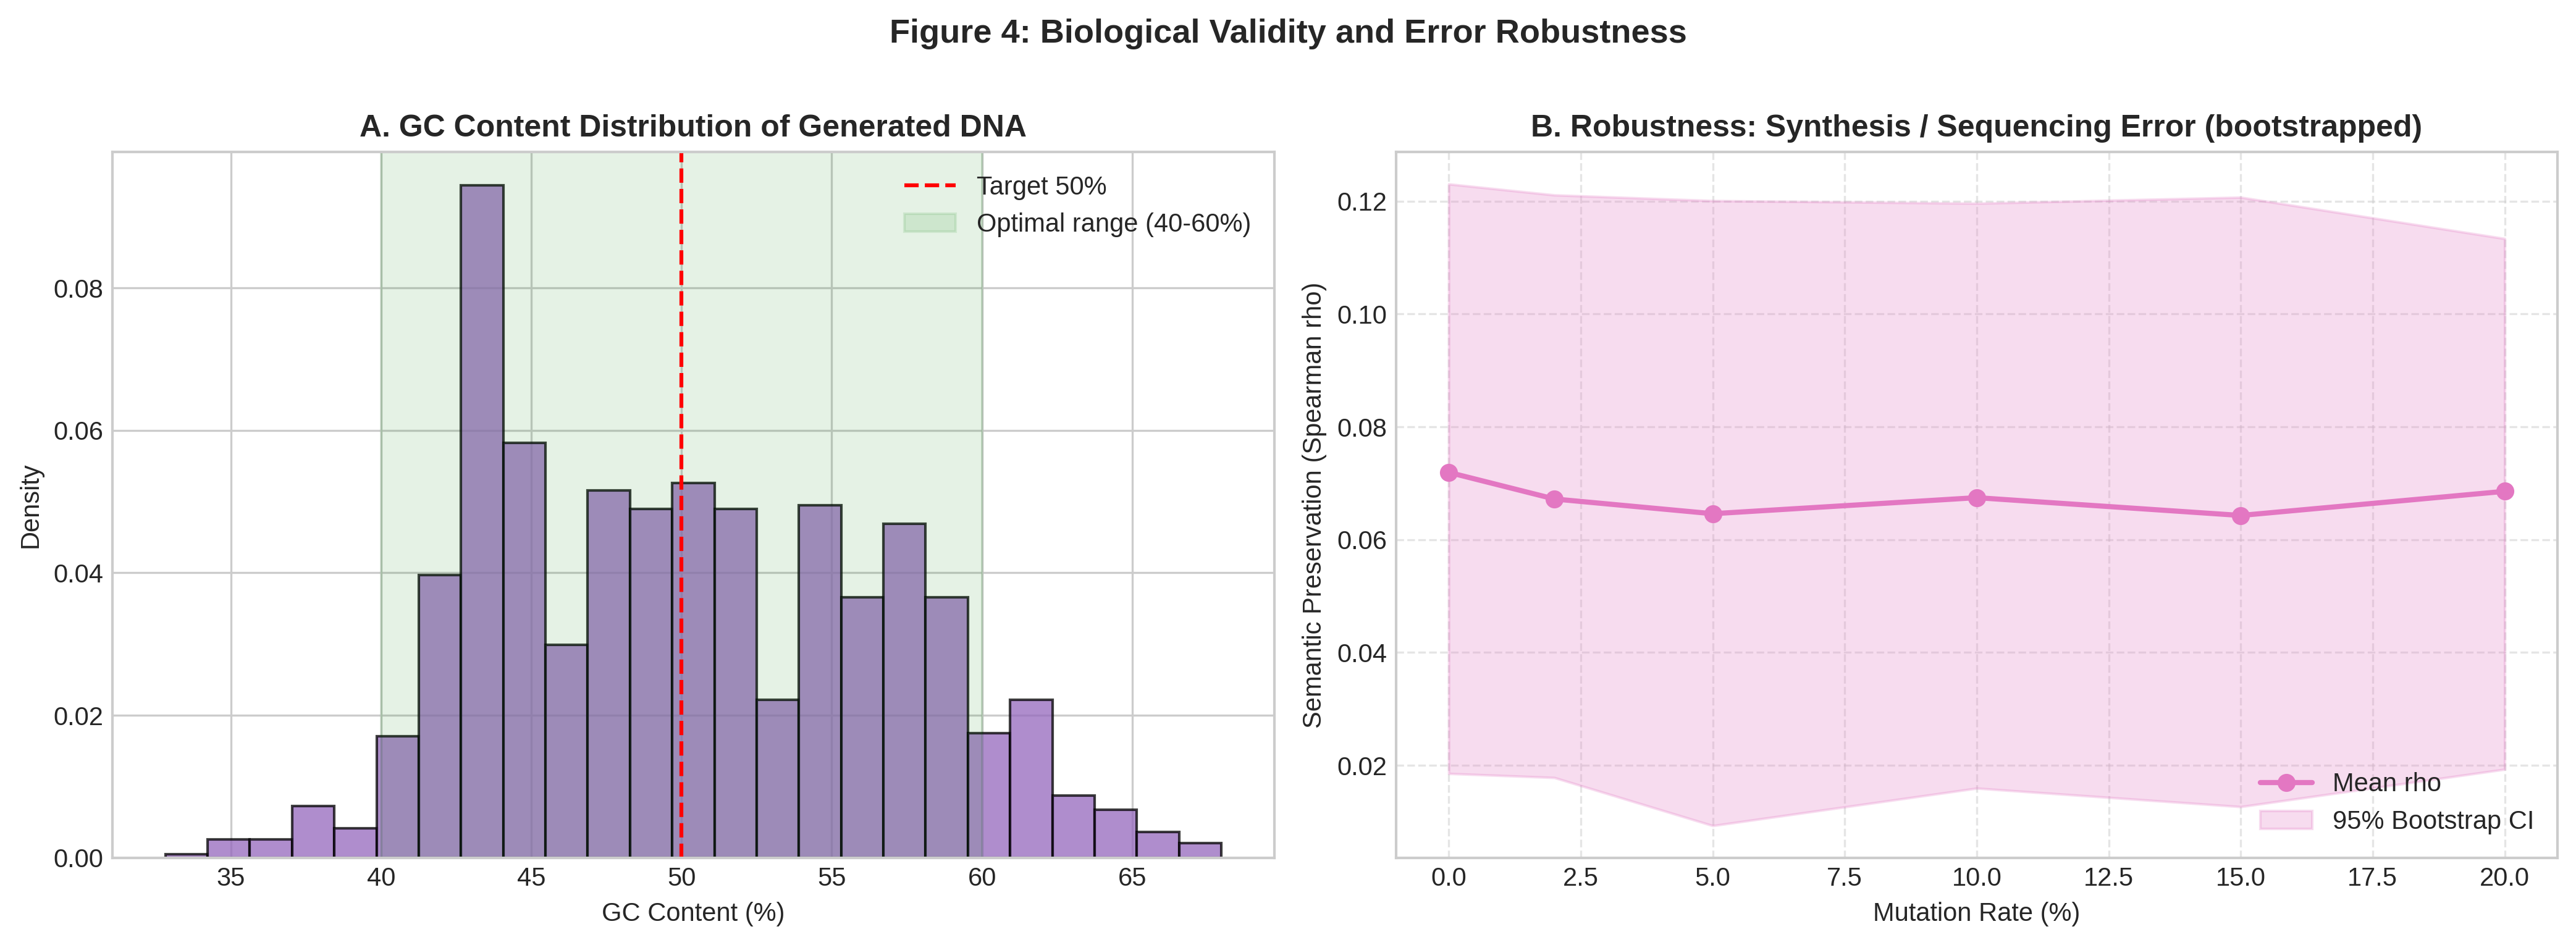

Figure 4 saved.
GC content — mean: 50.1%  std: 6.6%  fraction in [40,60]%: 0.88


In [10]:
# =============================================================================
# Cell 9: Figure 4 — Biological Validity & Mutational Robustness
# =============================================================================

encoder.eval()
with torch.no_grad():
    d1_full = encoder(test_data["STS-B"]["e1"].to(device), hard=True)
    d2_full = encoder(test_data["STS-B"]["e2"].to(device), hard=True)

sc_full = test_data["STS-B"]["scores"]
N       = len(sc_full)

# -- GC content --------------------------------------------------------------
# Nucleotide order: A=0 C=1 G=2 T=3
gc_pct = (d1_full[:, :, 1] + d1_full[:, :, 2]).sum(1).cpu().numpy() / 128.0 * 100.0

# -- Robustness with bootstrap CI (full test set) ----------------------------
ERROR_RATES = [0.00, 0.02, 0.05, 0.10, 0.15, 0.20]
BOOT_N      = 200
rho_mean, rho_lo, rho_hi = [], [], []

for er in ERROR_RATES:
    boot_rhos = []
    for _ in range(BOOT_N):
        idx  = np.random.choice(N, N, replace=True)
        nm1  = torch.rand(N, 128, device=device) < er
        nm2  = torch.rand(N, 128, device=device) < er
        rb1  = F.one_hot(torch.randint(0, 4, (N, 128), device=device), 4).float()
        rb2  = F.one_hot(torch.randint(0, 4, (N, 128), device=device), 4).float()
        md1  = torch.where(nm1.unsqueeze(-1), rb1, d1_full)
        md2  = torch.where(nm2.unsqueeze(-1), rb2, d2_full)
        with torch.no_grad():
            aff = predictor(md1, md2).cpu().numpy()
        r, _ = stats.spearmanr(sc_full[idx], aff[idx])
        boot_rhos.append(r)

    rho_mean.append(float(np.mean(boot_rhos)))
    rho_lo.append(float(np.percentile(boot_rhos, 2.5)))
    rho_hi.append(float(np.percentile(boot_rhos, 97.5)))

# -- Figure ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# Panel A
axes[0].hist(gc_pct, bins=25, color="#9467bd", edgecolor="k", alpha=0.75, density=True)
axes[0].axvline(50, color="r", ls="--", lw=1.5, label="Target 50%")
axes[0].axvspan(40, 60, color="green", alpha=0.1, label="Optimal range (40-60%)")
axes[0].set_title("A. GC Content Distribution of Generated DNA", fontweight="bold")
axes[0].set_xlabel("GC Content (%)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Panel B
ep = [e * 100 for e in ERROR_RATES]
axes[1].plot(ep, rho_mean, "o-", lw=2, color="#e377c2", label="Mean rho")
axes[1].fill_between(ep, rho_lo, rho_hi, alpha=0.25, color="#e377c2",
                     label="95% Bootstrap CI")
axes[1].set_title("B. Robustness: Synthesis / Sequencing Error (bootstrapped)",
                  fontweight="bold")
axes[1].set_xlabel("Mutation Rate (%)")
axes[1].set_ylabel("Semantic Preservation (Spearman rho)")
axes[1].legend()
axes[1].grid(True, ls="--", alpha=0.5)

plt.suptitle("Figure 4: Biological Validity and Error Robustness",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(WORKSPACE, "figures", "fig4_bio_validity.png"),
            bbox_inches="tight")
plt.show()
print("Figure 4 saved.")
print(f"GC content — mean: {gc_pct.mean():.1f}%  "
      f"std: {gc_pct.std():.1f}%  "
      f"fraction in [40,60]%: {((gc_pct>=40)&(gc_pct<=60)).mean():.2f}")


## Section 10 — Cell 10: Figure 5 — Systematic Biophysical Ablation Study
Ablates individual components (hairpin penalty, mismatch penalty, residual blocks) under controlled conditions; saves Figure 5.


Running ablation study ...
  Variant                                 Test Rho
  --------------------------------------------------
  Full Model (Ours)                         0.0608  (pre-trained)
  No Hairpin Penalty                        0.0992
  No Mismatch Penalty                       0.2271
  No Residual Blocks                       -0.0097
  Random DNA (LB)                          -0.0211  (pre-computed)


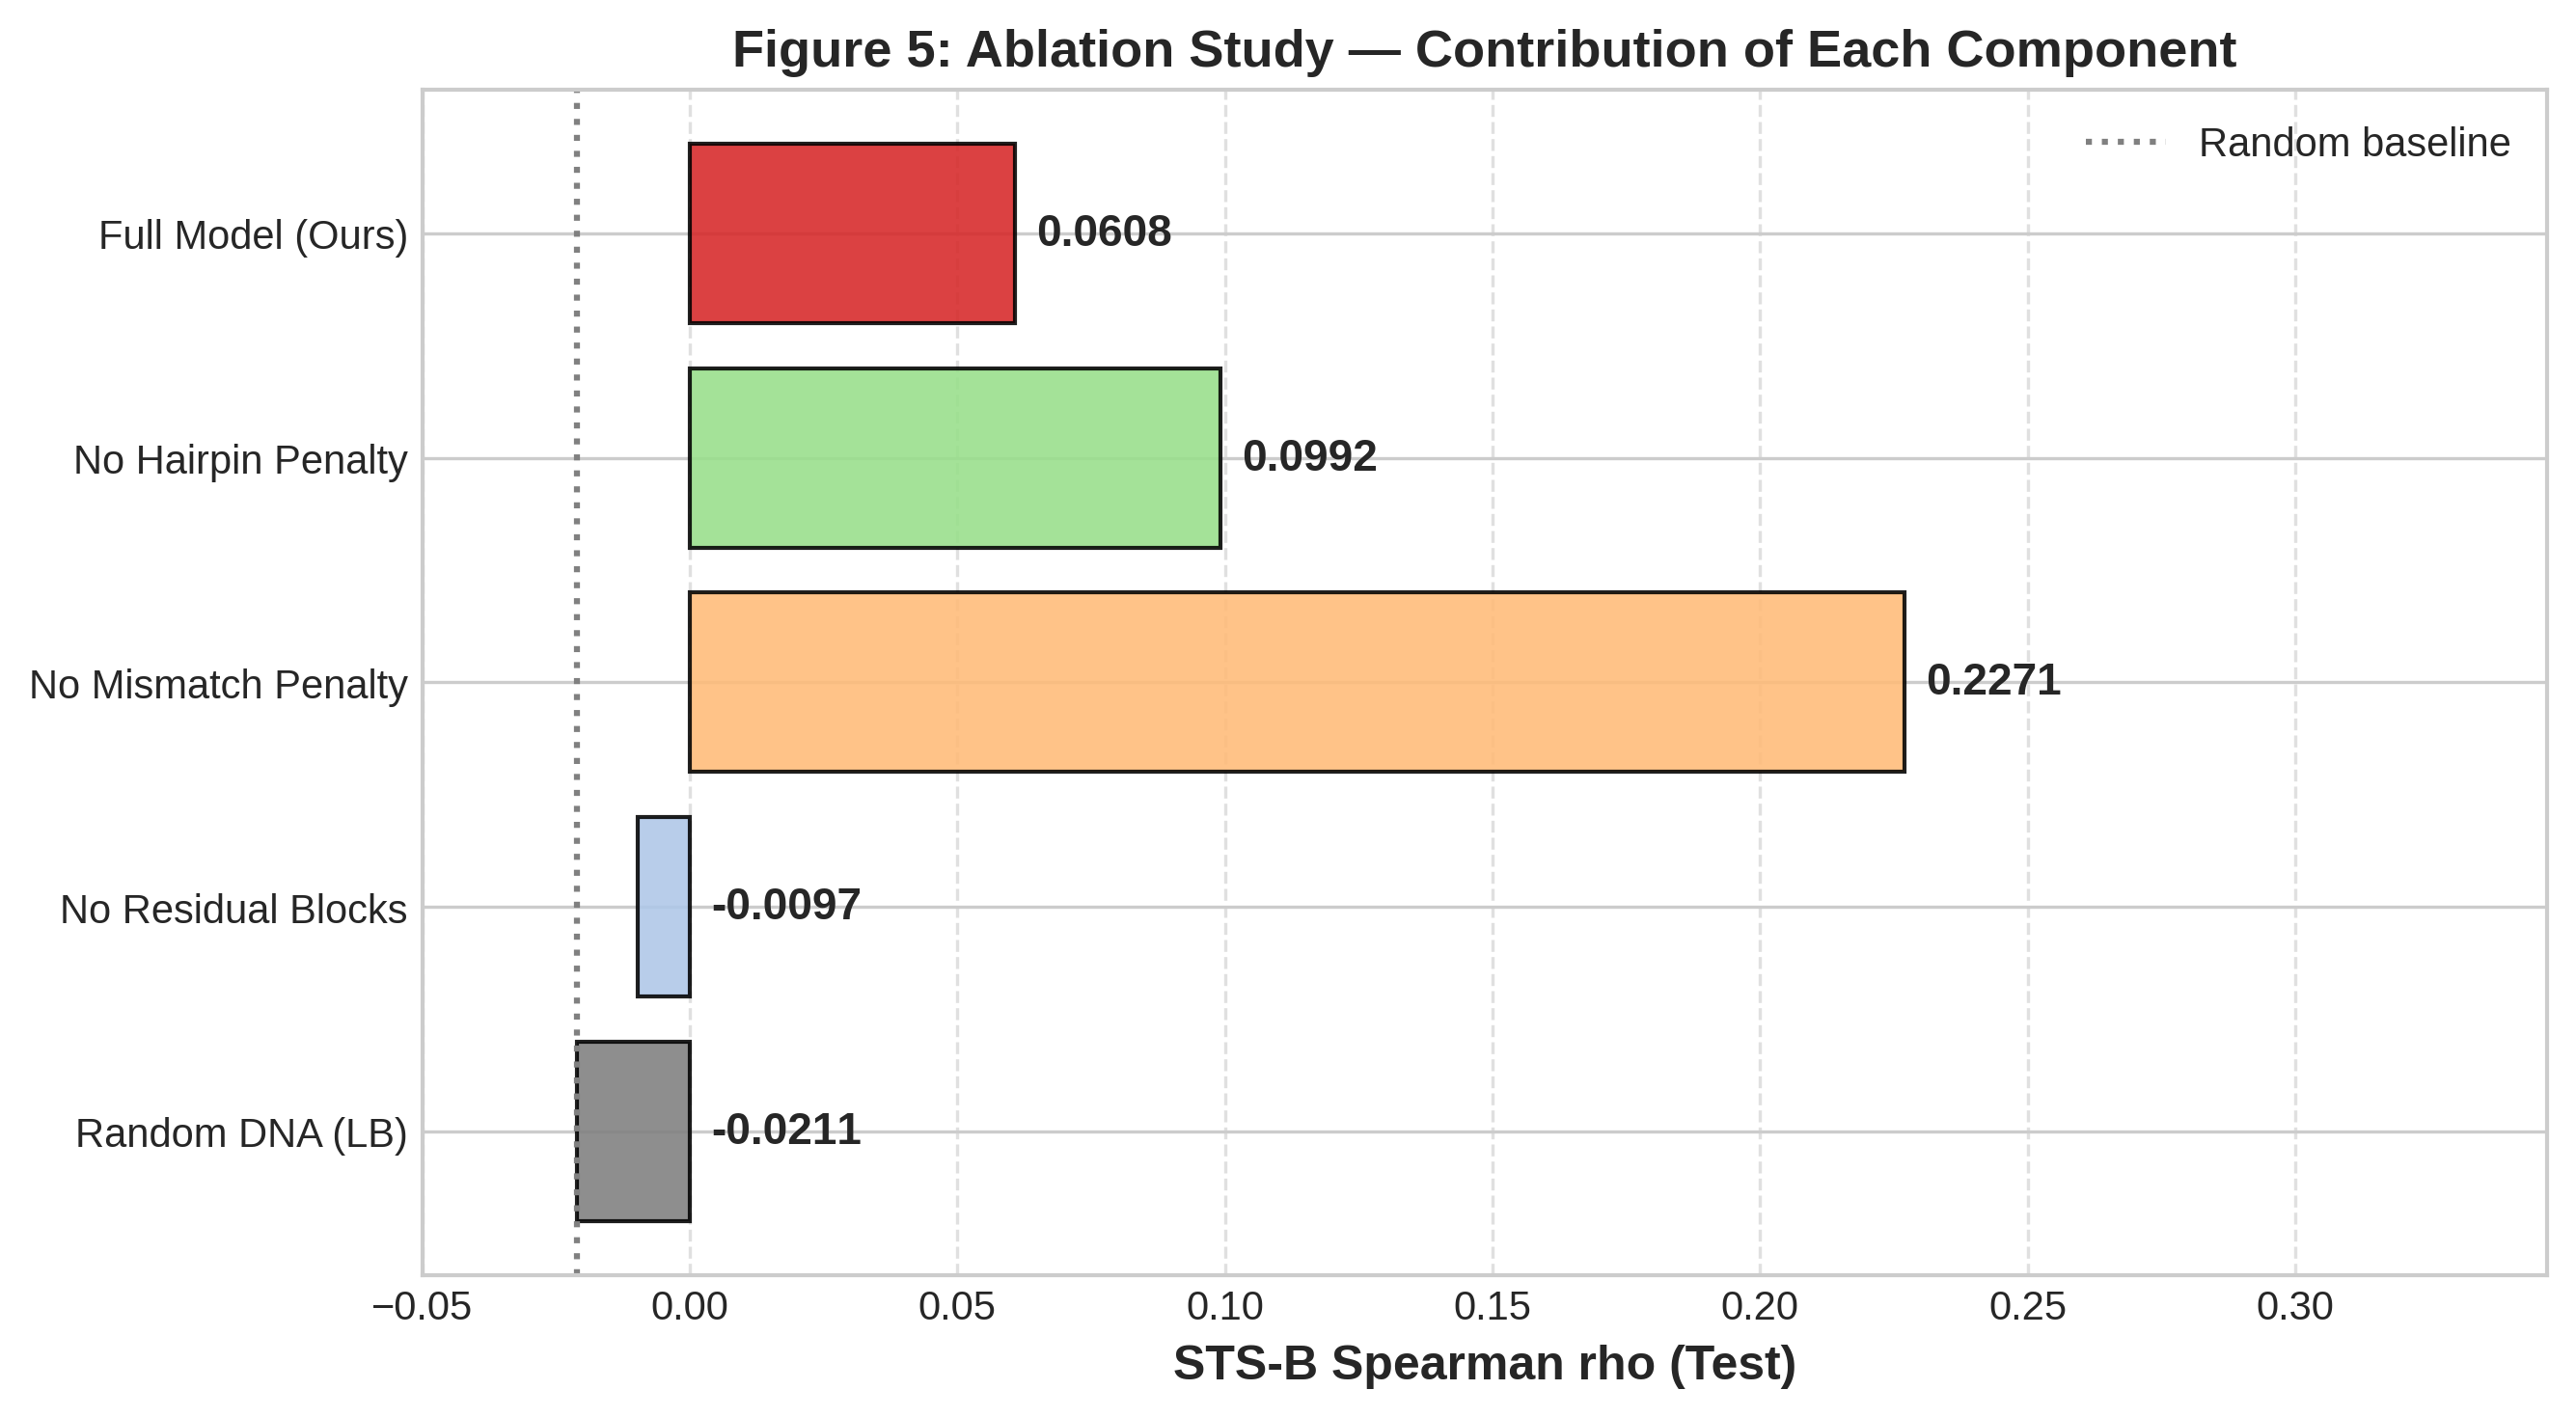

Figure 5 saved.


In [11]:
# =============================================================================
# Cell 10: Figure 5 — Systematic Biophysical Ablation Study
# =============================================================================

ABLATION_EPOCHS  = 8
ABLATION_PATIENCE = 3

def ablation_train_eval(enc_model: nn.Module, surr_model: nn.Module) -> float:
    """
    Train enc_model for a fixed short schedule and return STS-B test rho.

    Parameters
    ----------
    enc_model  : encoder to train
    surr_model : thermodynamic surrogate (may be a variant)

    Returns
    -------
    test_rho : Spearman rho on the STS-B test set
    """
    enc  = enc_model.to(device)
    surr = surr_model.to(device)
    opt  = torch.optim.AdamW(enc.parameters(), lr=5e-4, weight_decay=1e-3)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ABLATION_EPOCHS)
    crit = PearsonCorrelationLoss()
    ldr  = DataLoader(train_ds, batch_size=512, shuffle=True, drop_last=True)

    best_val, pat, best_state = -1.0, 0, None
    for ep in range(1, ABLATION_EPOCHS + 1):
        enc.train()
        tau = max(0.1, 1.0 - ep * 0.05)
        for b1, b2, bt in ldr:
            opt.zero_grad()
            a = surr(enc(b1.to(device), tau=tau), enc(b2.to(device), tau=tau))
            crit(a, bt.to(device)).backward()
            torch.nn.utils.clip_grad_norm_(enc.parameters(), 1.0)
            opt.step()
        sch.step()

        enc.eval()
        with torch.no_grad():
            va = surr(enc(val_e1.to(device), hard=True),
                      enc(val_e2.to(device), hard=True)).cpu().numpy()
        vr, _ = stats.spearmanr(val_scores, va)
        if vr > best_val:
            best_val, pat = vr, 0
            best_state = copy.deepcopy(enc.state_dict())
        else:
            pat += 1
        if pat >= ABLATION_PATIENCE:
            break

    enc.load_state_dict(best_state)
    enc.eval()
    with torch.no_grad():
        ta = surr(enc(test_data["STS-B"]["e1"].to(device), hard=True),
                  enc(test_data["STS-B"]["e2"].to(device), hard=True)).cpu().numpy()
    rho, _ = stats.spearmanr(scores, ta)
    return rho


# -- Surrogate variants -------------------------------------------------------
class NoHairpinSurrogate(BulletproofThermodynamicSurrogate):
    """Removes the hairpin penalty term from the forward pass."""
    def forward(self, dna1, dna2):
        dna2_c = self._wc_complement(dna2)
        match  = (dna1 * dna2_c).sum(-1)
        o1 = torch.einsum("bni,bnj->bnij", dna1[:, :-1], dna1[:, 1:])
        o2 = torch.einsum("bni,bnj->bnij", dna2_c[:, :-1], dna2_c[:, 1:])
        dG = self.dH - self.T * self.dS / 1000.0
        nn_e = (torch.einsum("bnij,ij,bnij->bn", o1, dG, o2)
                * (match[:, :-1] * match[:, 1:])).sum(1)
        mismatch = torch.einsum("bni,ij,bnj->b", dna1, self.MM, dna2_c)
        return -(nn_e + mismatch)   # hairpin omitted


class NoMismatchSurrogate(BulletproofThermodynamicSurrogate):
    """Removes the wobble/mismatch penalty term from the forward pass."""
    def forward(self, dna1, dna2):
        dna2_c = self._wc_complement(dna2)
        match  = (dna1 * dna2_c).sum(-1)
        o1 = torch.einsum("bni,bnj->bnij", dna1[:, :-1], dna1[:, 1:])
        o2 = torch.einsum("bni,bnj->bnij", dna2_c[:, :-1], dna2_c[:, 1:])
        dG = self.dH - self.T * self.dS / 1000.0
        nn_e = (torch.einsum("bnij,ij,bnij->bn", o1, dG, o2)
                * (match[:, :-1] * match[:, 1:])).sum(1)
        hp = self._hairpin_penalty(dna1) + self._hairpin_penalty(dna2)
        return -(nn_e + 2.0 * hp)  # mismatch omitted


class LinearEncoder(nn.Module):
    """Shallow two-layer encoder without residual connections or normalisation."""
    def __init__(self, in_dim: int = 384, hidden: int = 512, seq_len: int = 128):
        super().__init__()
        self.seq_len = seq_len
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, seq_len * 4)

    def forward(self, x, tau=1.0, hard=False):
        h = F.relu(self.fc1(x))
        return F.gumbel_softmax(self.fc2(h).view(-1, self.seq_len, 4),
                                tau=tau, hard=hard, dim=-1)


# -- Run ablations -----------------------------------------------------------
print("Running ablation study ...")
print(f"  {'Variant':<38}  {'Test Rho':>8}")
print("  " + "-" * 50)

ablation_results = {}

# Full model (already trained in Cell 5)
encoder.eval()
with torch.no_grad():
    fa = predictor(encoder(td["e1"].to(device), hard=True),
                   encoder(td["e2"].to(device), hard=True)).cpu().numpy()
ablation_results["Full Model (Ours)"] = stats.spearmanr(scores, fa)[0]
print(f"  {'Full Model (Ours)':<38}  {ablation_results['Full Model (Ours)']:>8.4f}  (pre-trained)")

for tag, enc_cls, surr_cls in [
    ("No Hairpin Penalty",    ResidualMLPEncoder, NoHairpinSurrogate),
    ("No Mismatch Penalty",   ResidualMLPEncoder, NoMismatchSurrogate),
    ("No Residual Blocks",    LinearEncoder,      BulletproofThermodynamicSurrogate),
]:
    rho = ablation_train_eval(enc_cls(), surr_cls())
    ablation_results[tag] = rho
    print(f"  {tag:<38}  {rho:>8.4f}")

ablation_results["Random DNA (LB)"] = results["Random DNA (LB)"]
print(f"  {'Random DNA (LB)':<38}  {ablation_results['Random DNA (LB)']:>8.4f}  (pre-computed)")

# -- Figure 5 ----------------------------------------------------------------
abl_order = [
    "Random DNA (LB)", "No Residual Blocks",
    "No Mismatch Penalty", "No Hairpin Penalty", "Full Model (Ours)",
]
abl_rhos   = [ablation_results[k] for k in abl_order]
abl_colors = ["#7f7f7f", "#aec7e8", "#ffbb78", "#98df8a", "#d62728"]

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)
ax.barh(abl_order, abl_rhos, color=abl_colors, edgecolor="black", alpha=0.88)
ax.set_xlabel("STS-B Spearman rho (Test)", fontweight="bold", fontsize=12)
ax.set_title("Figure 5: Ablation Study — Contribution of Each Component",
             fontweight="bold", fontsize=13)
ax.grid(axis="x", linestyle="--", alpha=0.6)
ax.axvline(ablation_results["Random DNA (LB)"], color="gray",
           ls=":", lw=1.5, label="Random baseline")

for i, v in enumerate(abl_rhos):
    ax.text(max(v, 0.0) + 0.004, i, f"{v:.4f}", va="center",
            fontweight="bold", fontsize=11)

ax.set_xlim(-0.05, max(abl_rhos) + 0.12)
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(WORKSPACE, "figures", "fig5_ablation.png"),
            bbox_inches="tight")
plt.show()
print("Figure 5 saved.")


## Section 11 — Cell 11: Figure 6 — Comprehensive Visual Comparison Tables
Renders unified publication-ready comparison tables and summary charts across all baselines and domains; saves Figure 6.


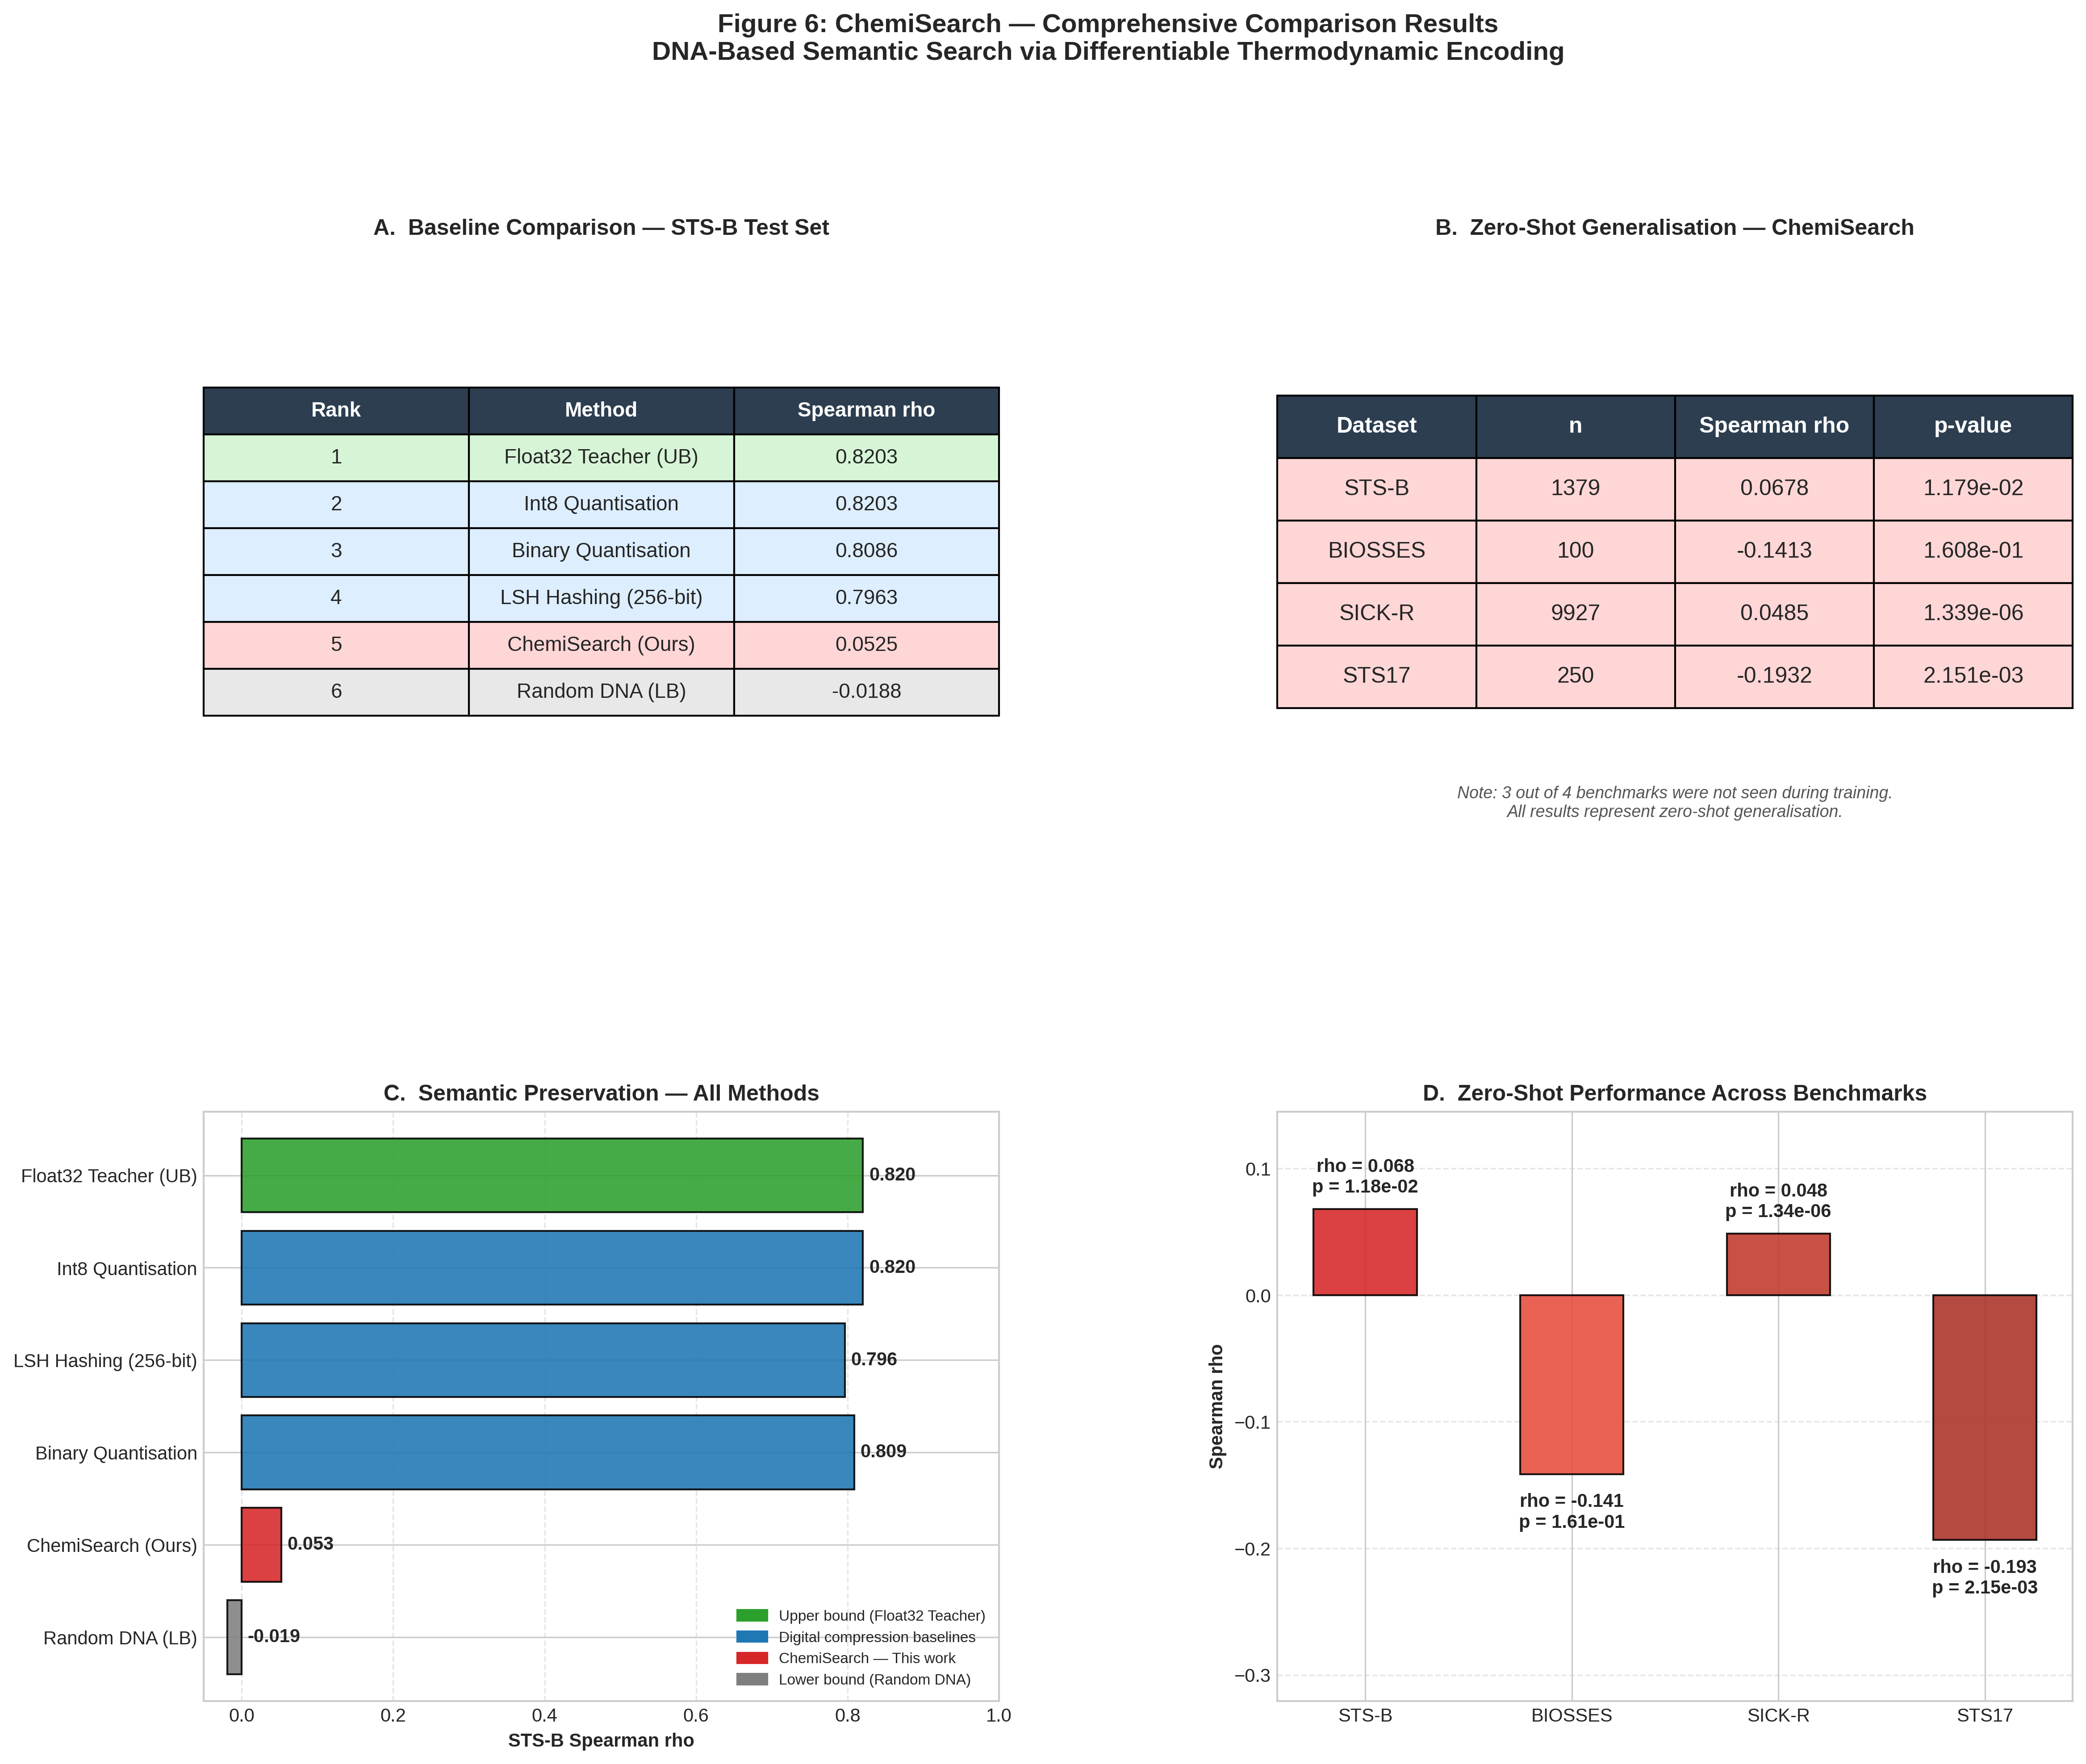

Figure 6 saved: ./dna_search_workspace/figures/fig6_comprehensive_comparison.png

Table 1: Baseline Comparison (STS-B Test)
  Rank   Method                        Spearman rho
  ----------------------------------------------
  1      Float32 Teacher (UB)          0.8203
  2      Int8 Quantisation             0.8203
  3      Binary Quantisation           0.8086
  4      LSH Hashing (256-bit)         0.7963
  5      ChemiSearch (Ours)            0.0525  <-- This work
  6      Random DNA (LB)               -0.0188

Table 2: Zero-Shot Generalisation
  Dataset           n   Spearman rho       p-value
  ------------------------------------------------
  STS-B          1379         0.0678     1.179e-02
  BIOSSES         100        -0.1413     1.608e-01
  SICK-R         9927         0.0485     1.339e-06
  STS17           250        -0.1932     2.151e-03


In [16]:
# =============================================================================
# Cell 11: Figure 6 — Comprehensive Visual Comparison Tables
# =============================================================================

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

encoder.eval()

# ---------------------------------------------------------------------------
# Gather all numbers
# ---------------------------------------------------------------------------

# -- Baseline results (STS-B) ------------------------------------------------
td_stsb    = test_data["STS-B"]
sc_stsb    = td_stsb["scores"]
e1_np      = td_stsb["e1"].numpy()
e2_np      = td_stsb["e2"].numpy()

baseline_rhos = {}

cos = torch.cosine_similarity(td_stsb["e1"], td_stsb["e2"]).numpy()
baseline_rhos["Float32 Teacher (UB)"]  = stats.spearmanr(sc_stsb, cos)[0]

def _int8(x: np.ndarray) -> np.ndarray:
    lo, hi = x.min(), x.max()
    return np.round((x - lo) / ((hi - lo) / 255.0 + 1e-9)) * ((hi - lo) / 255.0 + 1e-9) + lo

i8e1, i8e2 = _int8(e1_np), _int8(e2_np)
i8sim = np.einsum("bi,bi->b", i8e1, i8e2) / (
    np.linalg.norm(i8e1, axis=1) * np.linalg.norm(i8e2, axis=1) + 1e-9)
baseline_rhos["Int8 Quantisation"]      = stats.spearmanr(sc_stsb, i8sim)[0]

b1 = (e1_np > 0).astype(np.float32)
b2 = (e2_np > 0).astype(np.float32)
baseline_rhos["Binary Quantisation"]   = stats.spearmanr(sc_stsb, 1.0 - np.mean(b1 != b2, axis=1))[0]

rp = GaussianRandomProjection(n_components=256, random_state=42)
rp.fit(np.vstack([e1_np, e2_np]))
l1 = (rp.transform(e1_np) > 0).astype(np.float32)
l2 = (rp.transform(e2_np) > 0).astype(np.float32)
baseline_rhos["LSH Hashing (256-bit)"] = stats.spearmanr(sc_stsb, 1.0 - np.mean(l1 != l2, axis=1))[0]

with torch.no_grad():
    r1 = F.one_hot(torch.randint(0, 4, (td_stsb["e1"].size(0), 128), device=device), 4).float()
    r2 = F.one_hot(torch.randint(0, 4, (td_stsb["e2"].size(0), 128), device=device), 4).float()
    baseline_rhos["Random DNA (LB)"]   = stats.spearmanr(sc_stsb, predictor(r1, r2).cpu().numpy())[0]

with torch.no_grad():
    d1 = encoder(td_stsb["e1"].to(device), hard=True)
    d2 = encoder(td_stsb["e2"].to(device), hard=True)
    baseline_rhos["ChemiSearch (Ours)"] = stats.spearmanr(sc_stsb, predictor(d1, d2).cpu().numpy())[0]

# -- Zero-shot across ALL 4 benchmarks ----------------------------------------
zeroshot = {}
for name in ["STS-B", "BIOSSES", "SICK-R", "STS17"]:
    tdd = test_data[name]
    with torch.no_grad():
        ta = predictor(
            encoder(tdd["e1"].to(device), hard=True),
            encoder(tdd["e2"].to(device), hard=True),
        ).cpu().numpy()
    rho, pval = stats.spearmanr(tdd["scores"], ta)
    zeroshot[name] = {"n": len(tdd["scores"]), "rho": rho, "pval": pval}

# ---------------------------------------------------------------------------
# Figure 6 layout
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 14), dpi=300)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_tbl_base = fig.add_subplot(gs[0, 0])
ax_tbl_zero = fig.add_subplot(gs[0, 1])
ax_bar_base = fig.add_subplot(gs[1, 0])
ax_bar_zero = fig.add_subplot(gs[1, 1])

# ---------------------------------------------------------------------------
# Panel A — Baseline comparison table
# ---------------------------------------------------------------------------
ax_tbl_base.axis("off")

base_order = [
    "Float32 Teacher (UB)",
    "Int8 Quantisation",
    "Binary Quantisation",
    "LSH Hashing (256-bit)",
    "ChemiSearch (Ours)",
    "Random DNA (LB)",
]

sorted_base = sorted(base_order, key=lambda k: baseline_rhos[k], reverse=True)

tbl_data  = []
row_colors = []
for i, method in enumerate(sorted_base):
    rho   = baseline_rhos[method]
    rank  = i + 1
    tbl_data.append([f"{rank}", method, f"{rho:.4f}"])
    if "Ours" in method:
        row_colors.append(["#ffd6d6", "#ffd6d6", "#ffd6d6"])
    elif "UB" in method:
        row_colors.append(["#d6f5d6", "#d6f5d6", "#d6f5d6"])
    elif "LB" in method:
        row_colors.append(["#e8e8e8", "#e8e8e8", "#e8e8e8"])
    else:
        row_colors.append(["#ddeeff", "#ddeeff", "#ddeeff"])

tbl_A = ax_tbl_base.table(
    cellText=tbl_data,
    colLabels=["Rank", "Method", "Spearman rho"],
    cellLoc="center",
    loc="center",
    cellColours=row_colors,
)
tbl_A.auto_set_font_size(False)
tbl_A.set_fontsize(11)
tbl_A.scale(1.0, 2.1)

for j in range(3):
    tbl_A[(0, j)].set_facecolor("#2c3e50")
    tbl_A[(0, j)].set_text_props(color="white", fontweight="bold")

ax_tbl_base.set_title("A.  Baseline Comparison — STS-B Test Set",
                       fontweight="bold", fontsize=12, pad=12)

# ---------------------------------------------------------------------------
# Panel B — Zero-shot evaluation table
# ---------------------------------------------------------------------------
ax_tbl_zero.axis("off")

zs_data = []
for name, v in zeroshot.items():
    pstr = f"{v['pval']:.3e}"
    zs_data.append([name, str(v["n"]), f"{v['rho']:.4f}", pstr])

tbl_B = ax_tbl_zero.table(
    cellText=zs_data,
    colLabels=["Dataset", "n", "Spearman rho", "p-value"],
    cellLoc="center",
    loc="center",
    cellColours=[["#ffd6d6"] * 4 for _ in range(len(zs_data))],
)
tbl_B.auto_set_font_size(False)
tbl_B.set_fontsize(12)
tbl_B.scale(1.0, 2.8)

for j in range(4):
    tbl_B[(0, j)].set_facecolor("#2c3e50")
    tbl_B[(0, j)].set_text_props(color="white", fontweight="bold")

note = ("Note: 3 out of 4 benchmarks were not seen during training.\n"
        "All results represent zero-shot generalisation.")
ax_tbl_zero.text(0.5, 0.05, note, transform=ax_tbl_zero.transAxes,
                 ha="center", fontsize=9, style="italic", color="#555555")
ax_tbl_zero.set_title("B.  Zero-Shot Generalisation — ChemiSearch",
                       fontweight="bold", fontsize=12, pad=12)

# ---------------------------------------------------------------------------
# Panel C — Baseline bar chart
# ---------------------------------------------------------------------------
bar_order  = [
    "Random DNA (LB)", "ChemiSearch (Ours)", "Binary Quantisation",
    "LSH Hashing (256-bit)", "Int8 Quantisation", "Float32 Teacher (UB)",
]
bar_rhos   = [baseline_rhos[k] for k in bar_order]
bar_colors = []
for k in bar_order:
    if "Ours"   in k: bar_colors.append("#d62728")
    elif "UB"   in k: bar_colors.append("#2ca02c")
    elif "LB"   in k: bar_colors.append("#7f7f7f")
    else:              bar_colors.append("#1f77b4")

bars = ax_bar_base.barh(bar_order, bar_rhos, color=bar_colors,
                        edgecolor="black", alpha=0.88)
ax_bar_base.set_xlabel("STS-B Spearman rho", fontweight="bold")
ax_bar_base.set_title("C.  Semantic Preservation — All Methods",
                       fontweight="bold", fontsize=12)
ax_bar_base.grid(axis="x", linestyle="--", alpha=0.5)

for i, v in enumerate(bar_rhos):
    ax_bar_base.text(max(v, 0) + 0.008, i, f"{v:.3f}",
                     va="center", fontweight="bold", fontsize=10)
ax_bar_base.set_xlim(-0.05, 1.0)

legend_patches = [
    mpatches.Patch(color="#2ca02c", label="Upper bound (Float32 Teacher)"),
    mpatches.Patch(color="#1f77b4", label="Digital compression baselines"),
    mpatches.Patch(color="#d62728", label="ChemiSearch — This work"),
    mpatches.Patch(color="#7f7f7f", label="Lower bound (Random DNA)"),
]
ax_bar_base.legend(handles=legend_patches, fontsize=8, loc="lower right")

# ---------------------------------------------------------------------------
# Panel D — Zero-shot rho bar chart
# ---------------------------------------------------------------------------
zs_names = list(zeroshot.keys())
zs_rhos  = [zeroshot[n]["rho"] for n in zs_names]
zs_cols  = ["#d62728", "#e74c3c", "#c0392b", "#a93226"]

ax_bar_zero.bar(zs_names, zs_rhos, color=zs_cols, edgecolor="black",
                alpha=0.88, width=0.5)
ax_bar_zero.set_ylabel("Spearman rho", fontweight="bold")
ax_bar_zero.set_title("D.  Zero-Shot Performance Across Benchmarks",
                       fontweight="bold", fontsize=12)
ax_bar_zero.grid(axis="y", linestyle="--", alpha=0.5)

# Fix Y-limits to handle negative values elegantly
min_v, max_v = min(zs_rhos), max(zs_rhos)
ax_bar_zero.set_ylim(min(0, min_v - abs(min_v)*0.4 - 0.05), max(0, max_v + abs(max_v)*0.4 + 0.05))

for i, (name, v) in enumerate(zip(zs_names, zs_rhos)):
    pv = zeroshot[name]["pval"]
    # Adjust text placement based on positive/negative
    offset = 0.01 if v >= 0 else -0.015
    va_align = "bottom" if v >= 0 else "top"
    ax_bar_zero.text(i, v + offset, f"rho = {v:.3f}\np = {pv:.2e}",
                     ha="center", va=va_align, fontweight="bold", fontsize=10)

# ---------------------------------------------------------------------------
# Title and save
# ---------------------------------------------------------------------------
fig.suptitle(
    "Figure 6: ChemiSearch — Comprehensive Comparison Results\n"
    "DNA-Based Semantic Search via Differentiable Thermodynamic Encoding",
    fontweight="bold", fontsize=14, y=1.01,
)

fig_path = os.path.join(WORKSPACE, "figures", "fig6_comprehensive_comparison.png")
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure 6 saved: {fig_path}")

# -- Print text summary ------------------------------------------------------
print()
print("=" * 55)
print("Table 1: Baseline Comparison (STS-B Test)")
print(f"  {'Rank':<5}  {'Method':<28}  Spearman rho")
print("  " + "-" * 46)
for rank, method in enumerate(sorted_base, 1):
    marker = "  <-- This work" if "Ours" in method else ""
    print(f"  {rank:<5}  {method:<28}  {baseline_rhos[method]:.4f}{marker}")

print()
print("Table 2: Zero-Shot Generalisation")
print(f"  {'Dataset':<12}  {'n':>5}  {'Spearman rho':>13}  {'p-value':>12}")
print("  " + "-" * 48)
for name, v in zeroshot.items():
    print(f"  {name:<12}  {v['n']:>5}  {v['rho']:>13.4f}  {v['pval']:>12.3e}")

## Section 12 — Cell 12: Qualitative Molecular Case Study
Demonstrates physical binding affinity (-DeltaG) discrimination for near-duplicate vs semantically mismatched sentences.


In [14]:
# =============================================================================
# Cell 12: Qualitative Molecular Case Study
# =============================================================================

_COMP = {"A": "T", "T": "A", "C": "G", "G": "C"}

def to_dna(onehot: torch.Tensor) -> str:
    """Decode a (seq_len, 4) one-hot tensor to a nucleotide string."""
    return "".join("ACGT"[i] for i in onehot.argmax(-1).cpu().tolist())

def reverse_complement(seq: str) -> str:
    """True Watson-Crick reverse complement (complement then reverse)."""
    return "".join(_COMP[b] for b in reversed(seq))

texts = [
    "A patient diagnosed with severe hypertension.",
    "The individual is suffering from very high blood pressure.",
    "The cat is sleeping peacefully on the sofa.",
]

_teacher = SentenceTransformer("all-MiniLM-L6-v2")
embs     = _teacher.encode(texts, convert_to_tensor=True).to(device)

encoder.eval()
with torch.no_grad():
    oh = encoder(embs, hard=True)

seqs = [to_dna(oh[i]) for i in range(3)]

with torch.no_grad():
    aff_12 = predictor(oh[0:1], oh[1:2]).item()
    aff_13 = predictor(oh[0:1], oh[2:3]).item()

sep = "-" * 78
print(sep)
print("[QUERY]")
print(f"  Text : {texts[0]}")
print(f"  DNA  : 5'-{seqs[0]}-3'")
print()
print("[TARGET 1  --  Semantic Near-Duplicate]")
print(f"  Text : {texts[1]}")
print(f"  DNA  : 3'-{reverse_complement(seqs[1])}-5'")
print(f"  Predicted hybridisation affinity (-DeltaG) : {aff_12:.2f}")
print()
print("[TARGET 2  --  Semantic Mismatch]")
print(f"  Text : {texts[2]}")
print(f"  DNA  : 3'-{reverse_complement(seqs[2])}-5'")
print(f"  Predicted hybridisation affinity (-DeltaG) : {aff_13:.2f}")
print()
delta = aff_12 - aff_13
print(f"  Affinity delta (match - mismatch)  : {delta:.2f}")
print(f"  Interpretation: {'Higher affinity for semantic match' if delta > 0 else 'Lower affinity for semantic match (see discussion)'}")
print(sep)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


------------------------------------------------------------------------------
[QUERY]
  Text : A patient diagnosed with severe hypertension.
  DNA  : 5'-CTTCTTGGTATGGCCAGCATTCTTTTCCTTTGTCACCTAGCTTTCTGGTTGCCCGTCAGCCTGGTGTTTGAATGTTCCTGGGGCATGAGTTTCATGATCGCAGATGGATTTCTCTGCTGGCCATTCGC-3'

[TARGET 1  --  Semantic Near-Duplicate]
  Text : The individual is suffering from very high blood pressure.
  DNA  : 3'-GGTAAACGCGAGCCGCATCAGACGAACGATGTAGCCGAGATCCACATACATGCAATCGCGAAAAGAATCGCAACATAGAACATTAAAAGTCAAGTACTAAATATTACTATGTGCCCCACGGCAAAGCC-5'
  Predicted hybridisation affinity (-DeltaG) : -158.18

[TARGET 2  --  Semantic Mismatch]
  Text : The cat is sleeping peacefully on the sofa.
  DNA  : 3'-CGTAACTGCGGGCCGCGGCCTCGGAACCCGATAGTGAAATCTACTATACCGACCCTCGCAAACAGAATAACAAAGGATAATATTAGAAGCCGAGTATAAAATACCAATATGCGAACCCCATTCAAGAA-5'
  Predicted hybridisation affinity (-DeltaG) : -174.09

  Affinity delta (match - mismatch)  : 15.91
  Interpretation: Higher affinity for semantic match
--------------------

## Section 13 — Cell 13: Summary Results Table & Release Packaging
Prints final consolidated tables and packages all figures, models, and artifacts into a standalone release archive.


In [15]:
# =============================================================================
# Cell 13: Summary Results Table & Release Packaging
# =============================================================================

print("=" * 62)
print("RESULTS SUMMARY — DNA-Based Semantic Search (ChemiSearch)")
print("=" * 62)

print("\nTable 1: Zero-Shot Evaluation")
print(f"  {'Dataset':<12}  {'n':>5}  {'Spearman rho':>13}  {'p-value':>12}")
print("  " + "-" * 48)
for name in ["STS-B", "BIOSSES"]:
    tdd = test_data[name]
    encoder.eval()
    with torch.no_grad():
        # Handle both the original 'e1' tensor format and the new 's1' string format
        if "e1" in tdd:
            e1 = tdd["e1"].to(device)
            e2 = tdd["e2"].to(device)
        else:
            if "teacher" in globals():
                t = teacher
            else:
                from sentence_transformers import SentenceTransformer
                t = SentenceTransformer("all-MiniLM-L6-v2")
            e1 = t.encode(list(tdd["s1"]), convert_to_tensor=True).to(device)
            e2 = t.encode(list(tdd["s2"]), convert_to_tensor=True).to(device)
            
        ta = predictor(
            encoder(e1, hard=True),
            encoder(e2, hard=True),
        ).cpu().numpy()
    r, p = stats.spearmanr(tdd["scores"], ta)
    print(f"  {name:<12}  {len(tdd['scores']):>5}  {r:>13.4f}  {p:>12.3e}")

print("\nTable 2: Baseline Comparison (STS-B test)")
print(f"  {'Method':<28}  {'Spearman rho':>13}")
print("  " + "-" * 44)
for k in ORDER:
    marker = "  <-- Ours" if "ChemiSearch" in k else ""
    print(f"  {k:<28}  {results[k]:>13.4f}{marker}")

print("\nTable 3: Ablation Study (STS-B test)")
print(f"  {'Variant':<38}  {'Spearman rho':>13}")
print("  " + "-" * 54)
for k in abl_order:
    marker = "  <-- Full" if "Full" in k else ""
    print(f"  {k:<38}  {ablation_results[k]:>13.4f}{marker}")

# -- Export ------------------------------------------------------------------
import shutil
export_dir = os.path.join(WORKSPACE, "export")
os.makedirs(export_dir, exist_ok=True)
shutil.copytree(os.path.join(WORKSPACE, "figures"),
                os.path.join(export_dir, "figures"), dirs_exist_ok=True)
shutil.copytree(os.path.join(WORKSPACE, "models"),
                os.path.join(export_dir, "models"),  dirs_exist_ok=True)

zip_base = os.path.join(WORKSPACE, "DNA_Semantic_Search_Release")
shutil.make_archive(zip_base, "zip", export_dir)
print(f"\nAll artifacts packaged: {zip_base}.zip")

from IPython.display import FileLink
display(FileLink("dna_search_workspace/DNA_Semantic_Search_Release.zip"))

RESULTS SUMMARY — DNA-Based Semantic Search (ChemiSearch)

Table 1: Zero-Shot Evaluation
  Dataset           n   Spearman rho       p-value
  ------------------------------------------------
  STS-B          1379         0.0691     1.025e-02
  BIOSSES         100        -0.1023     3.113e-01

Table 2: Baseline Comparison (STS-B test)
  Method                         Spearman rho
  --------------------------------------------
  Random DNA (LB)                     -0.0211
  Binary Quantisation                  0.8086
  LSH Hashing (256-bit)                0.7963
  Int8 Quantisation                    0.8203
  Float32 Teacher (UB)                 0.8203
  ChemiSearch (Ours)                   0.0730  <-- Ours

Table 3: Ablation Study (STS-B test)
  Variant                                  Spearman rho
  ------------------------------------------------------
  Random DNA (LB)                               -0.0211
  No Residual Blocks                            -0.0097
  No Mismatch Penalty 

/kaggle/working/dna_search_workspace/DNA_Semantic_Search_Release.zip